In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.seasonal import STL

PROJECT_ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.fetch_h1z16_with_weather import build_engine, fetch_meter_data, fetch_weather_data, validate_columns

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

heat_meter_config = {
    'V.K21': ['Tdiff', 'qv', 'P'],
    'H1.K11': ['Tdiff', 'qv', 'P'],
    'H1.K12': ['Tdiff', 'P'],
    'H1.K14': ['Tdiff', 'qv', 'P'],
    'H1.K15': ['Tdiff', 'P'],
    'H1.K16': ['Tdiff', 'qv', 'P'],
    'H2.K21': ['Tdiff', 'qv', 'P'],
    'H1.W11': ['Tdiff', 'qv', 'P'],
    'H1.W12': ['Tdiff', 'qv', 'P'],
}

COOLING = ['V.K21', 'H1.K11', 'H1.K12', 'H1.K14', 'H1.K15', 'H1.K16', 'H2.K21']
HEATING = ['H1.W11', 'H1.W12']

SPECIAL_PERIODS = {
    'H2.K21': [('2021-11-15', '2021-12-10', 'gray', '게이트웨이 장애')],
    'H1.W11': [('2023-01-01', '2023-12-31', 'lightblue', '난방 현대화')],
}

METER_NOTES = {
    'V.K21': 'qv 유량 센서 고장 이력 2회 (논문)',
    'H1.K11': '2022년 초 결측 구간',
    'H1.K12': '2023년 완전 미가동 (P=0 확정)',
    'H1.K15': '거의 미가동 상태',
    'H2.K21': '2021.11.15~12.10 게이트웨이 장애 (논문)',
    'H1.W11': '2023년 난방 현대화, 운영 조건 변화 (논문)',
    'H1.W12': '여름 qv≈0 은 CHP 미가동 정상',
}

PERIOD = 24 * 7
SEASONAL = 13
SIGMA = 3

engine = build_engine()
weather_df = fetch_weather_data(engine).copy()
weather_df['ts'] = pd.to_datetime(weather_df['ts'], utc=True, errors='coerce')
for col in ['Ta', 'Igm']:
    if col in weather_df.columns:
        weather_df[col] = pd.to_numeric(weather_df[col], errors='coerce')

def load_heat_meter_raw(meter_urn: str) -> pd.DataFrame:
    df_main = fetch_meter_data(engine, meter_urn).copy()
    validate_columns(df_main, meter_urn)
    df_main['ts'] = pd.to_datetime(df_main['ts'], utc=True, errors='coerce')
    merged = df_main.merge(weather_df, on='ts', how='left').sort_values('ts').reset_index(drop=True)
    for col in merged.columns:
        if col not in ['ts', 'meter_urn']:
            merged[col] = pd.to_numeric(merged[col], errors='coerce')
    return merged

raw_meter_data = {meter_urn: load_heat_meter_raw(meter_urn) for meter_urn in heat_meter_config}
list(raw_meter_data.keys())


['V.K21',
 'H1.K11',
 'H1.K12',
 'H1.K14',
 'H1.K15',
 'H1.K16',
 'H2.K21',
 'H1.W11',
 'H1.W12']

In [2]:
v_df = raw_meter_data['V.K21'].copy().sort_values('ts')
v_qv = pd.to_numeric(v_df['qv'], errors='coerce')
v_roll_std = v_qv.rolling(24).std()
v_2022 = float(v_roll_std[v_df['ts'].dt.year == 2022].mean())
v_2023 = float(v_roll_std[v_df['ts'].dt.year == 2023].mean())
v_frozen = pd.notna(v_2022) and pd.notna(v_2023) and v_2023 < (v_2022 * 0.3)

print('[V.K21 qv 고착 확인]')
print(f'  2022년 rolling std 평균: {v_2022:.2f}')
print(f'  2023년 rolling std 평균: {v_2023:.2f}')
print(f"  → 판정: {'고착 의심' if v_frozen else '정상'}")
print()

h_df = raw_meter_data['H2.K21'].copy().sort_values('ts')
h_tdiff = pd.to_numeric(h_df['Tdiff'], errors='coerce')
h_roll_std = h_tdiff.rolling(24).std()
fault_start = pd.Timestamp('2021-11-15', tz='UTC')
fault_end = pd.Timestamp('2021-12-10 23:59:59', tz='UTC')
prev_start = fault_start - pd.Timedelta(days=30)
prev_end = fault_start - pd.Timedelta(hours=1)
prev_mask = h_df['ts'].between(prev_start, prev_end)
fault_mask = h_df['ts'].between(fault_start, fault_end)
prev_mean = float(h_roll_std[prev_mask].mean())
fault_mean = float(h_roll_std[fault_mask].mean())
fault_unique = int(h_tdiff[fault_mask].nunique(dropna=True))
h_frozen = (
    pd.notna(prev_mean)
    and pd.notna(fault_mean)
    and fault_mean < (prev_mean * 0.3)
    and fault_unique <= 3
)

print('[H2.K21 Tdiff 게이트웨이 장애 구간 확인]')
print(f'  직전 30일 rolling std 평균: {prev_mean:.2f}')
print(f'  장애 구간 rolling std 평균: {fault_mean:.2f}')
print(f'  장애 구간 unique 값 개수: {fault_unique}')
print(f"  → 판정: {'고착 의심' if h_frozen else '정상'}")


[V.K21 qv 고착 확인]
  2022년 rolling std 평균: 4.53
  2023년 rolling std 평균: 0.89
  → 판정: 고착 의심

[H2.K21 Tdiff 게이트웨이 장애 구간 확인]
  직전 30일 rolling std 평균: 202.50
  장애 구간 rolling std 평균: 227.61
  장애 구간 unique 값 개수: 609
  → 판정: 정상


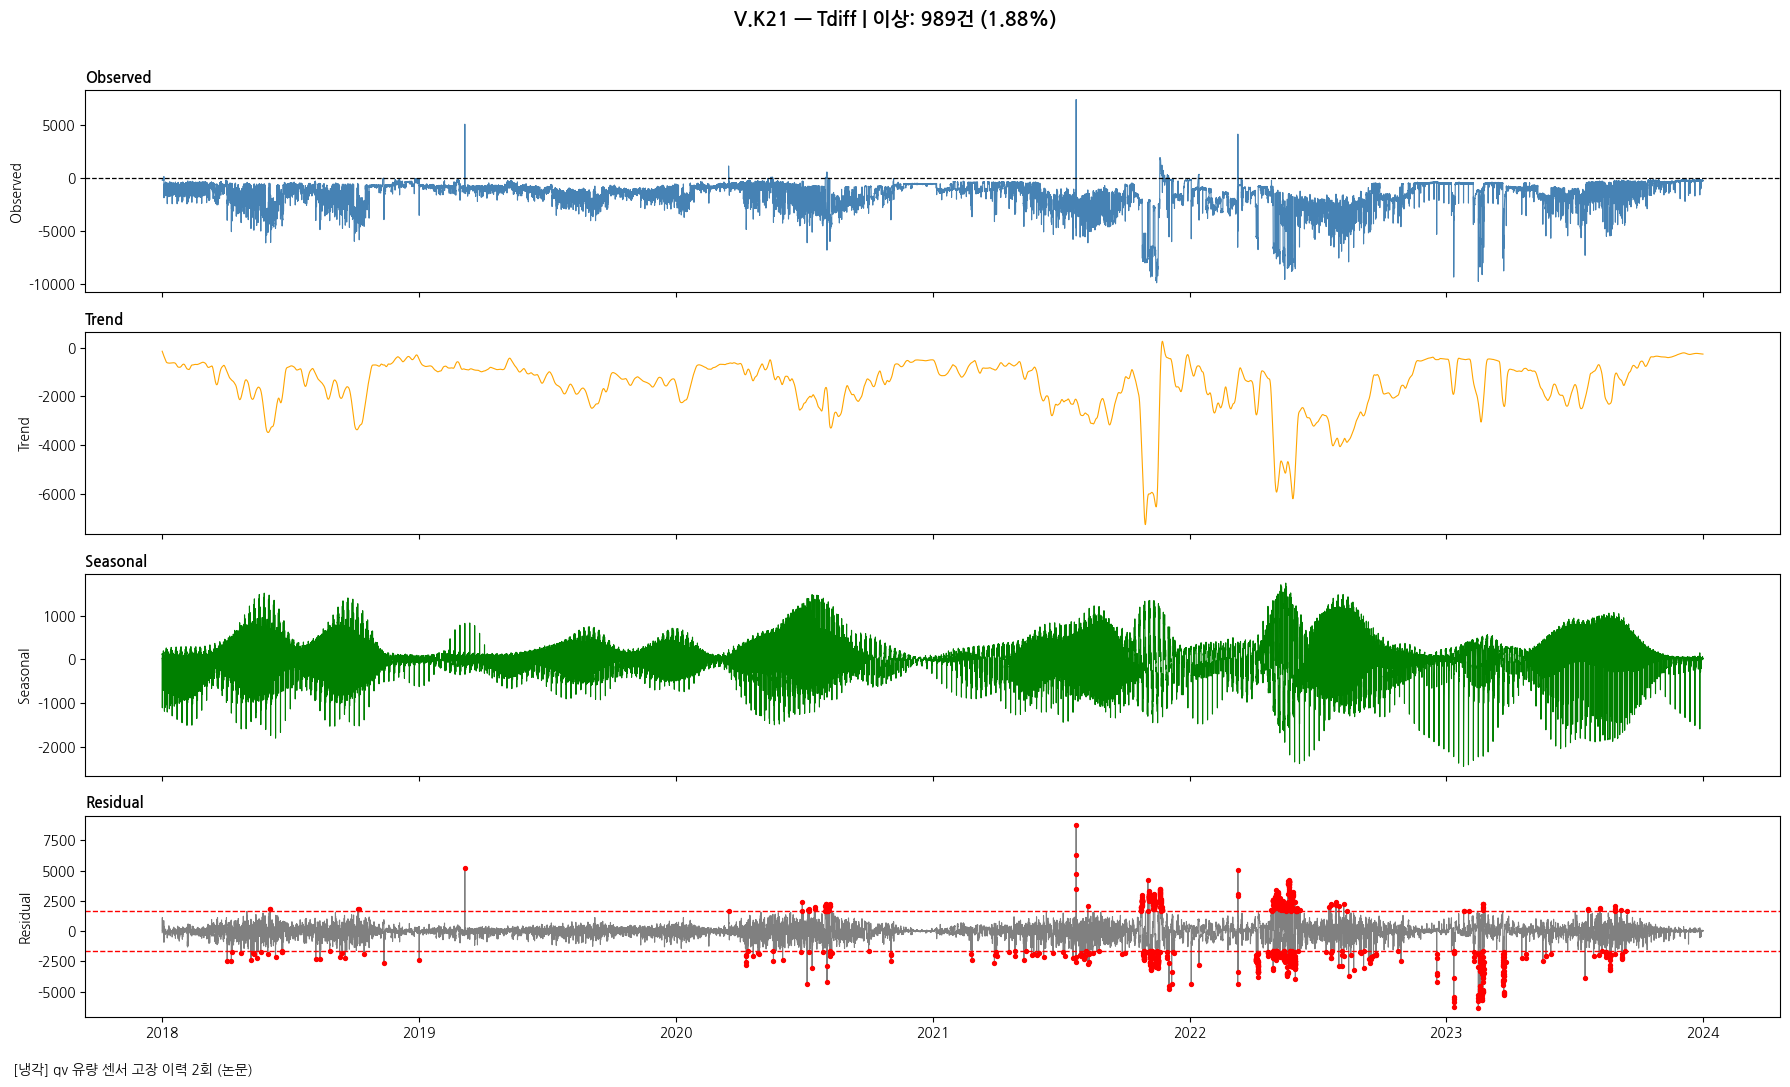

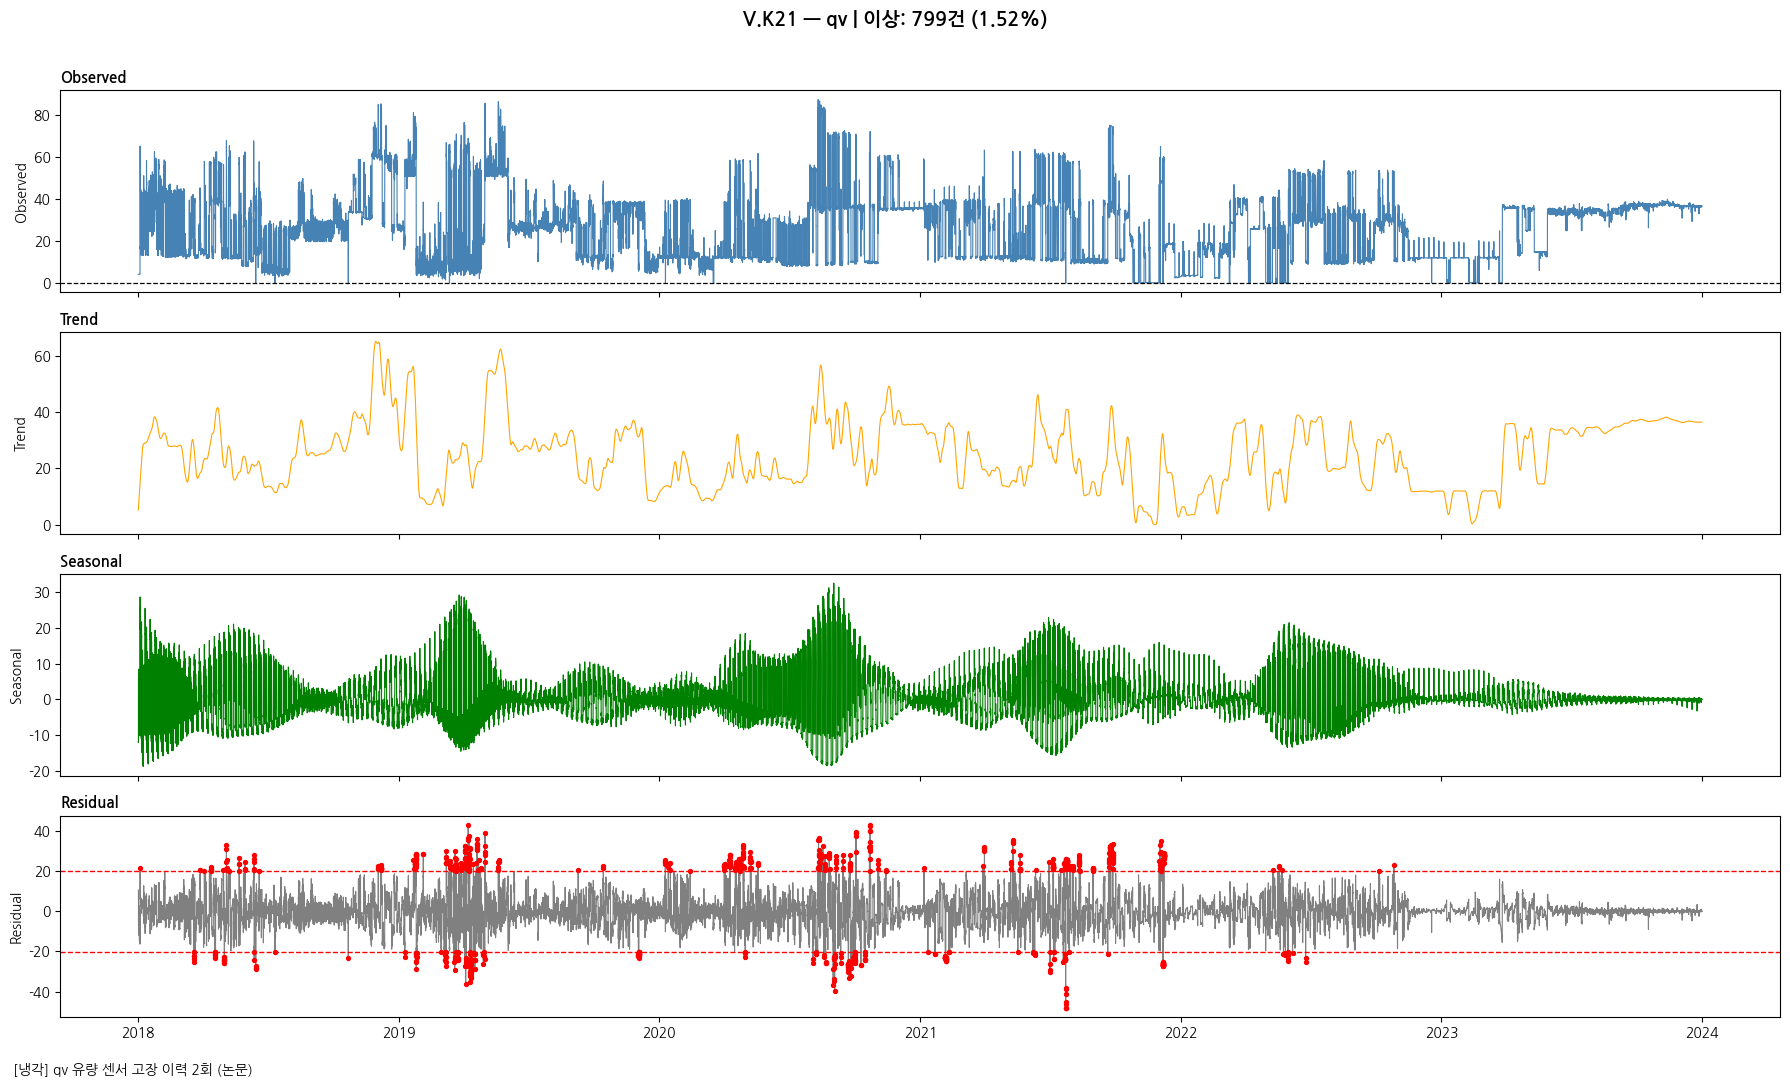

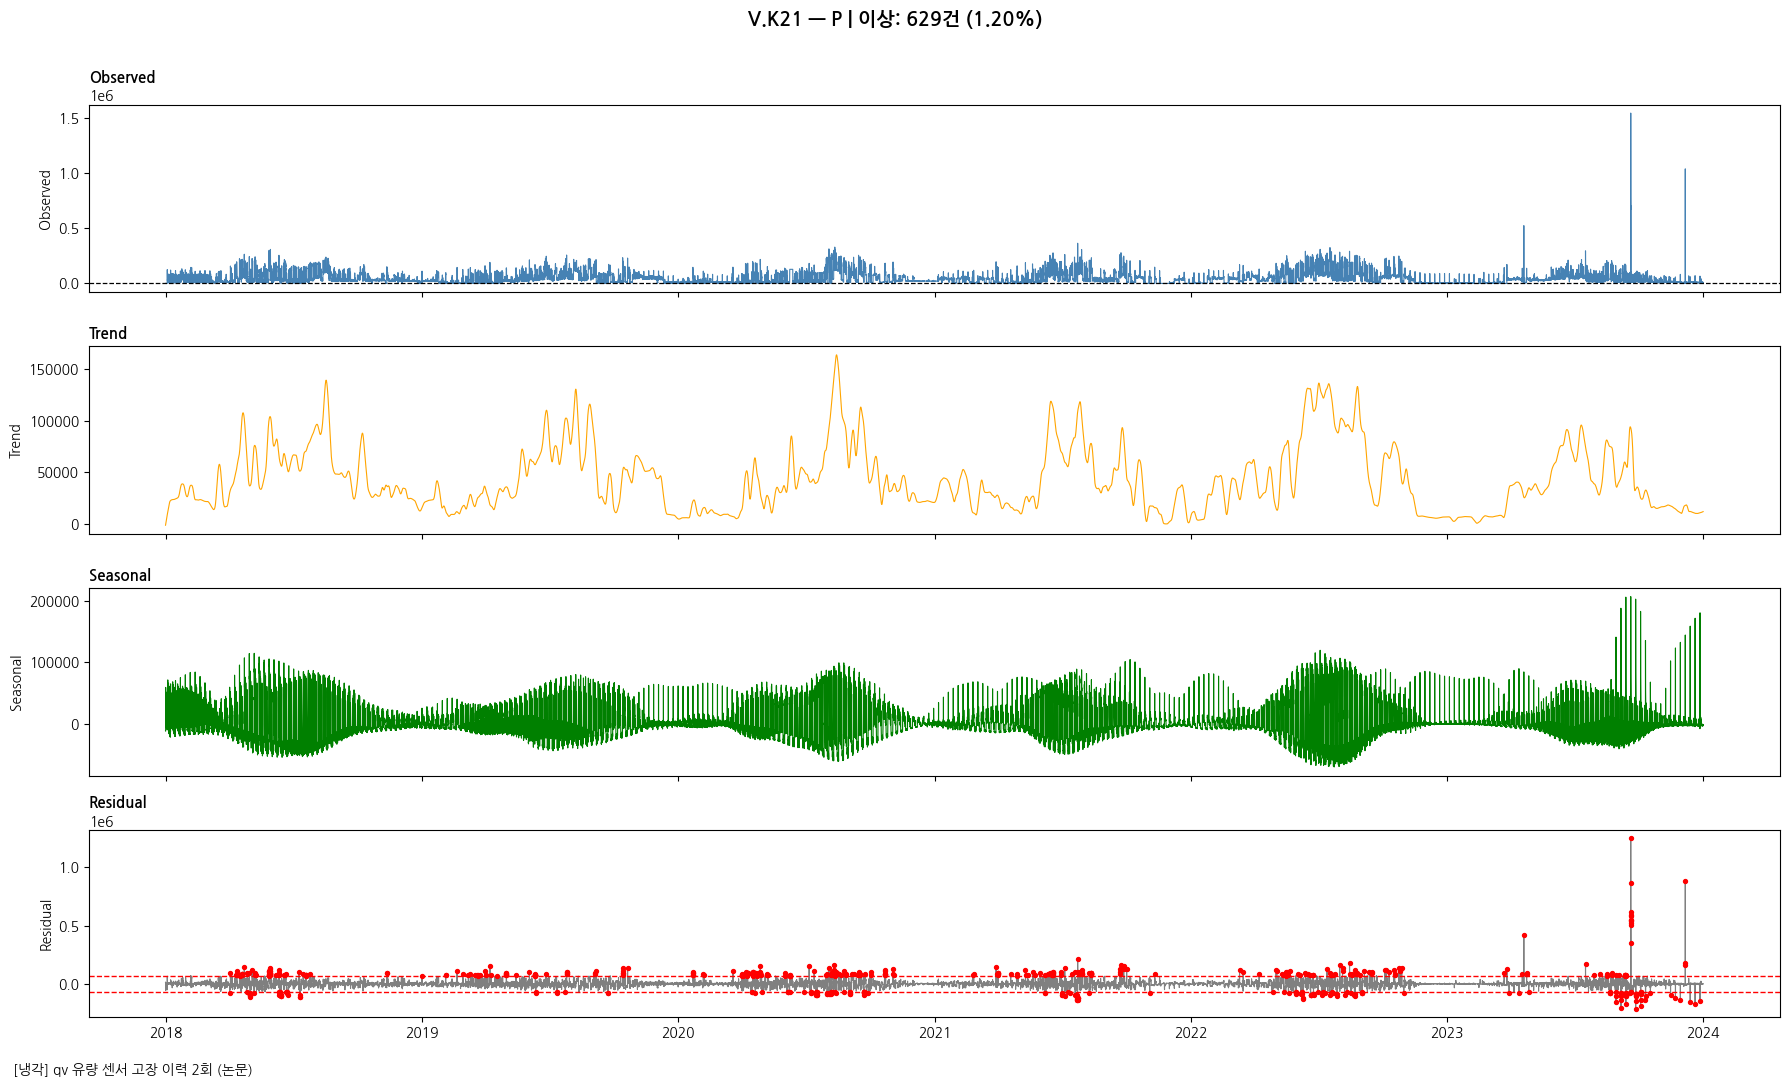

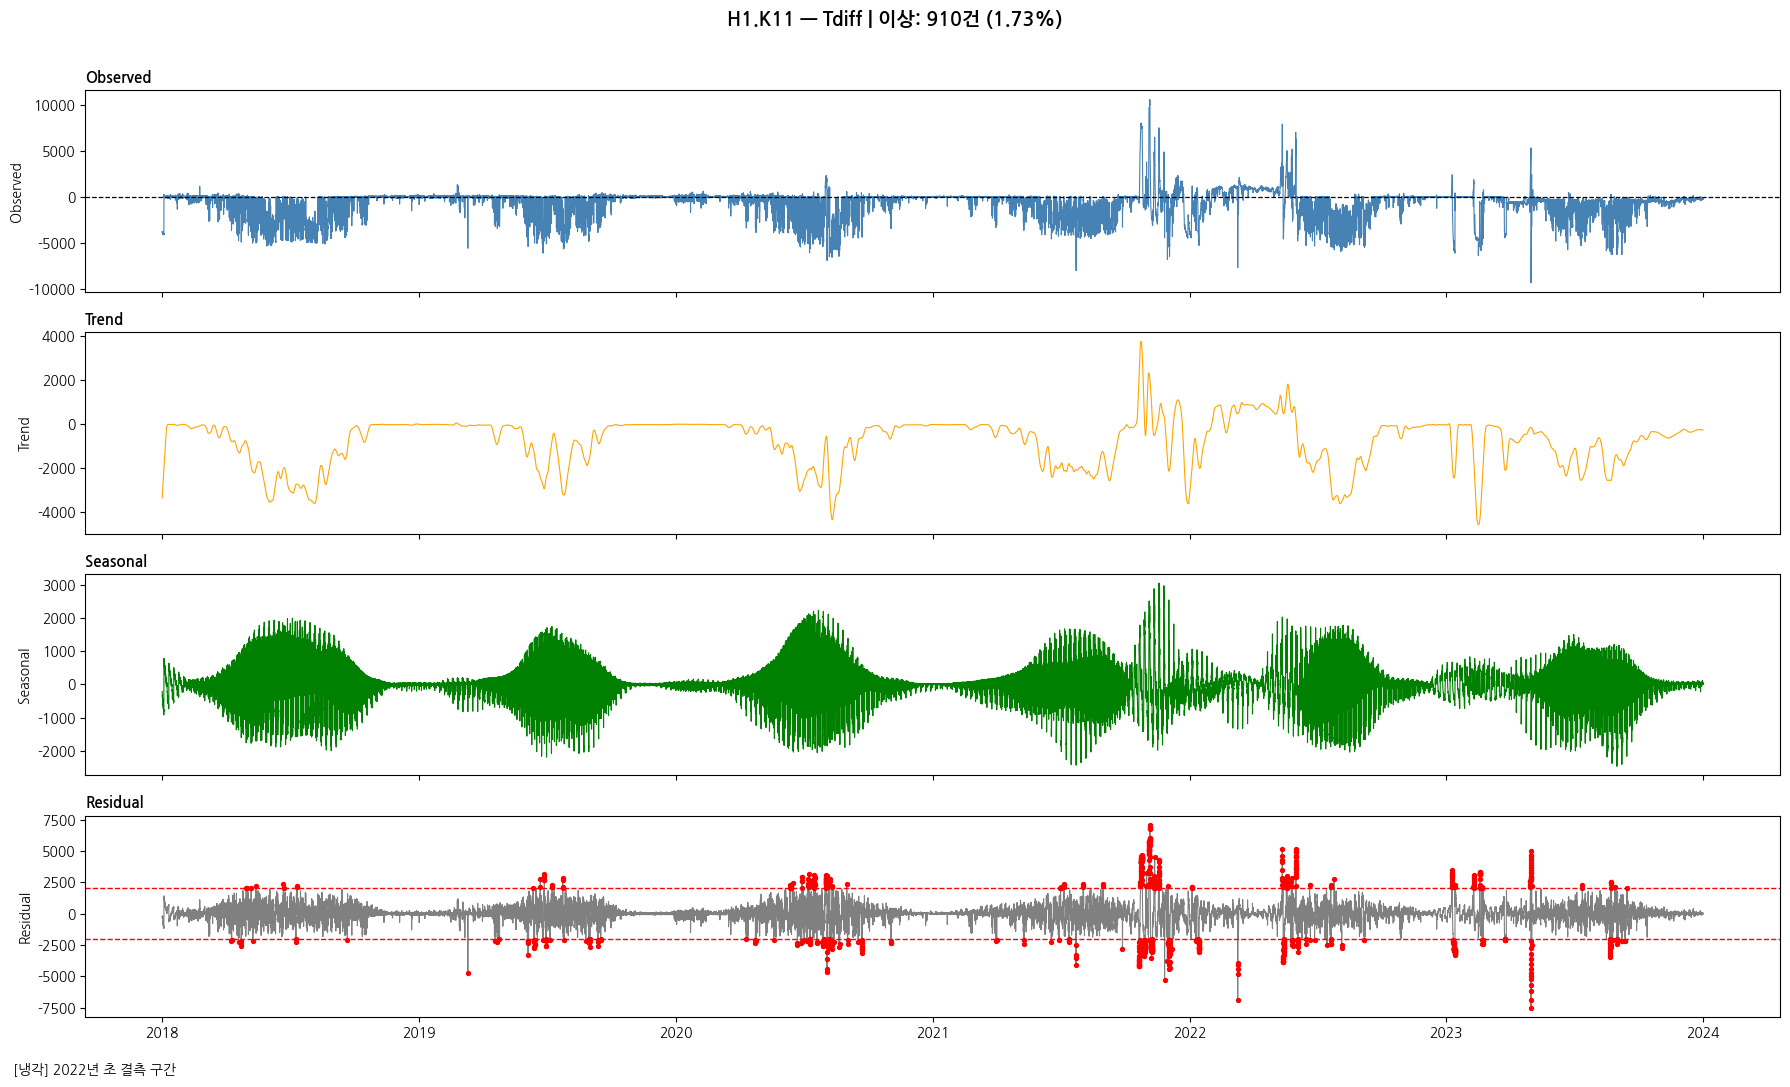

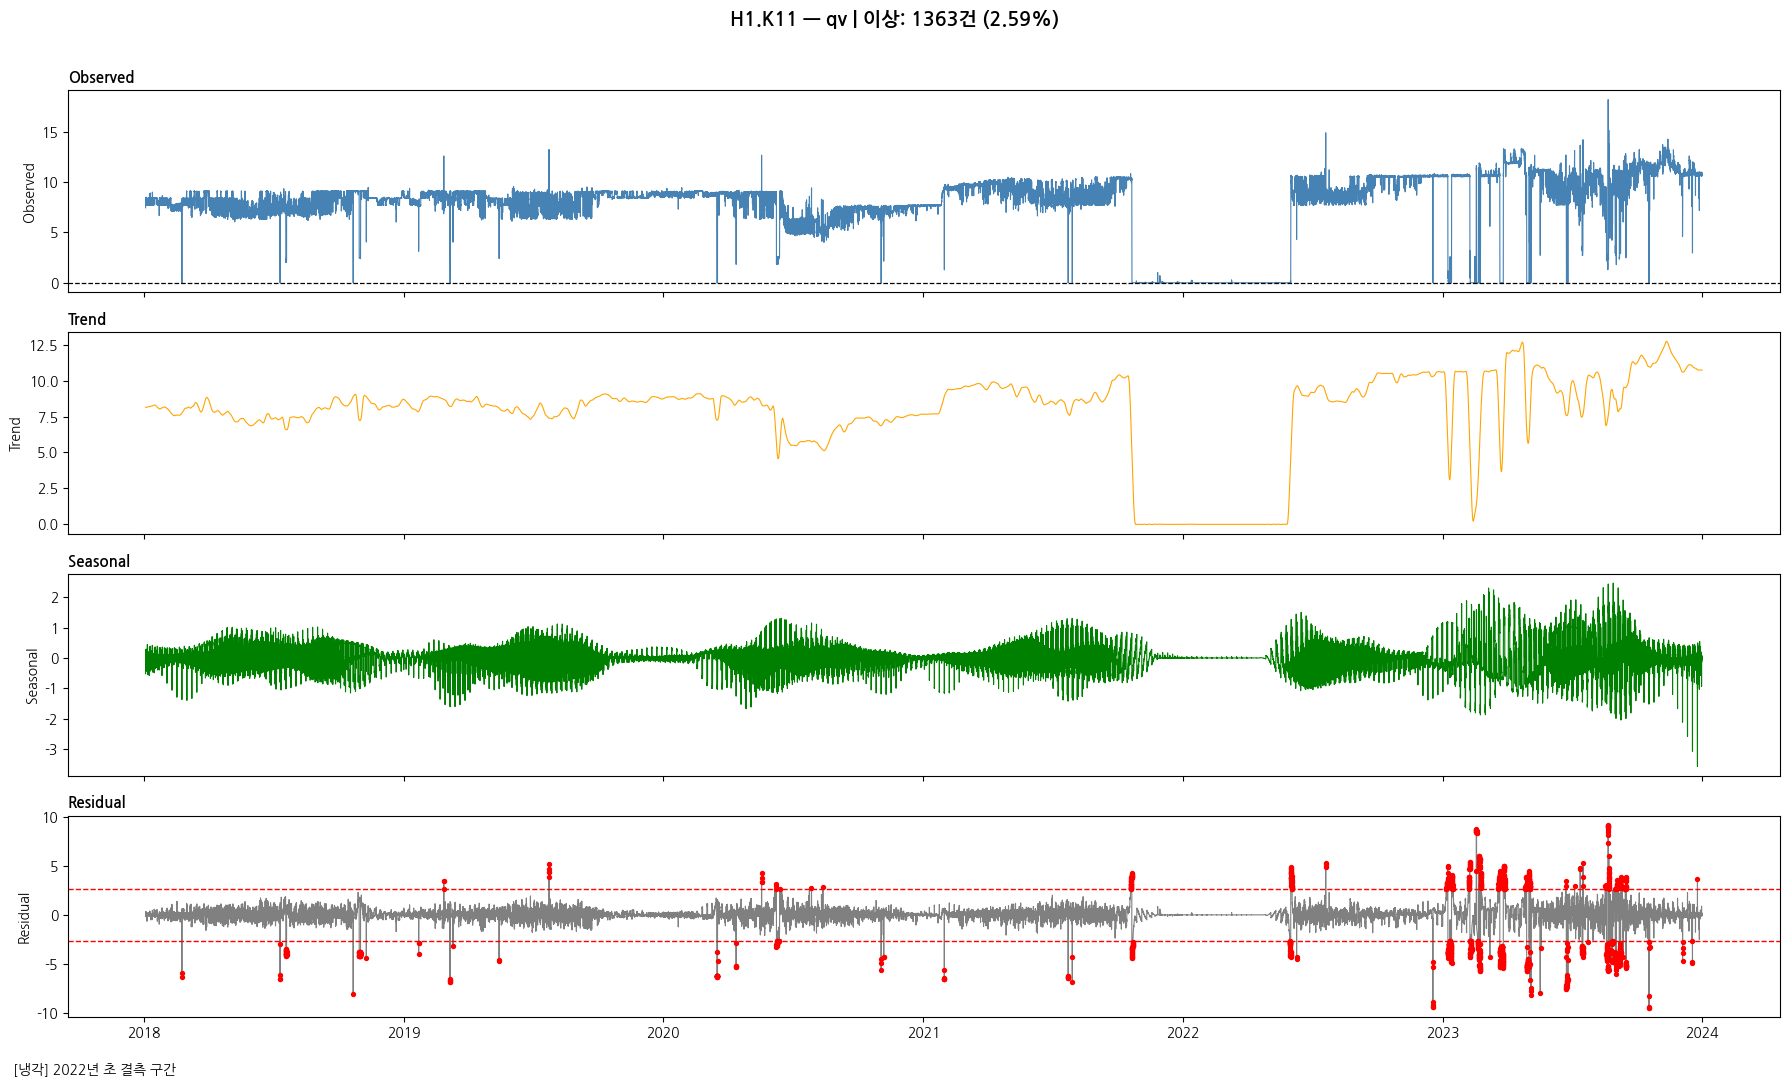

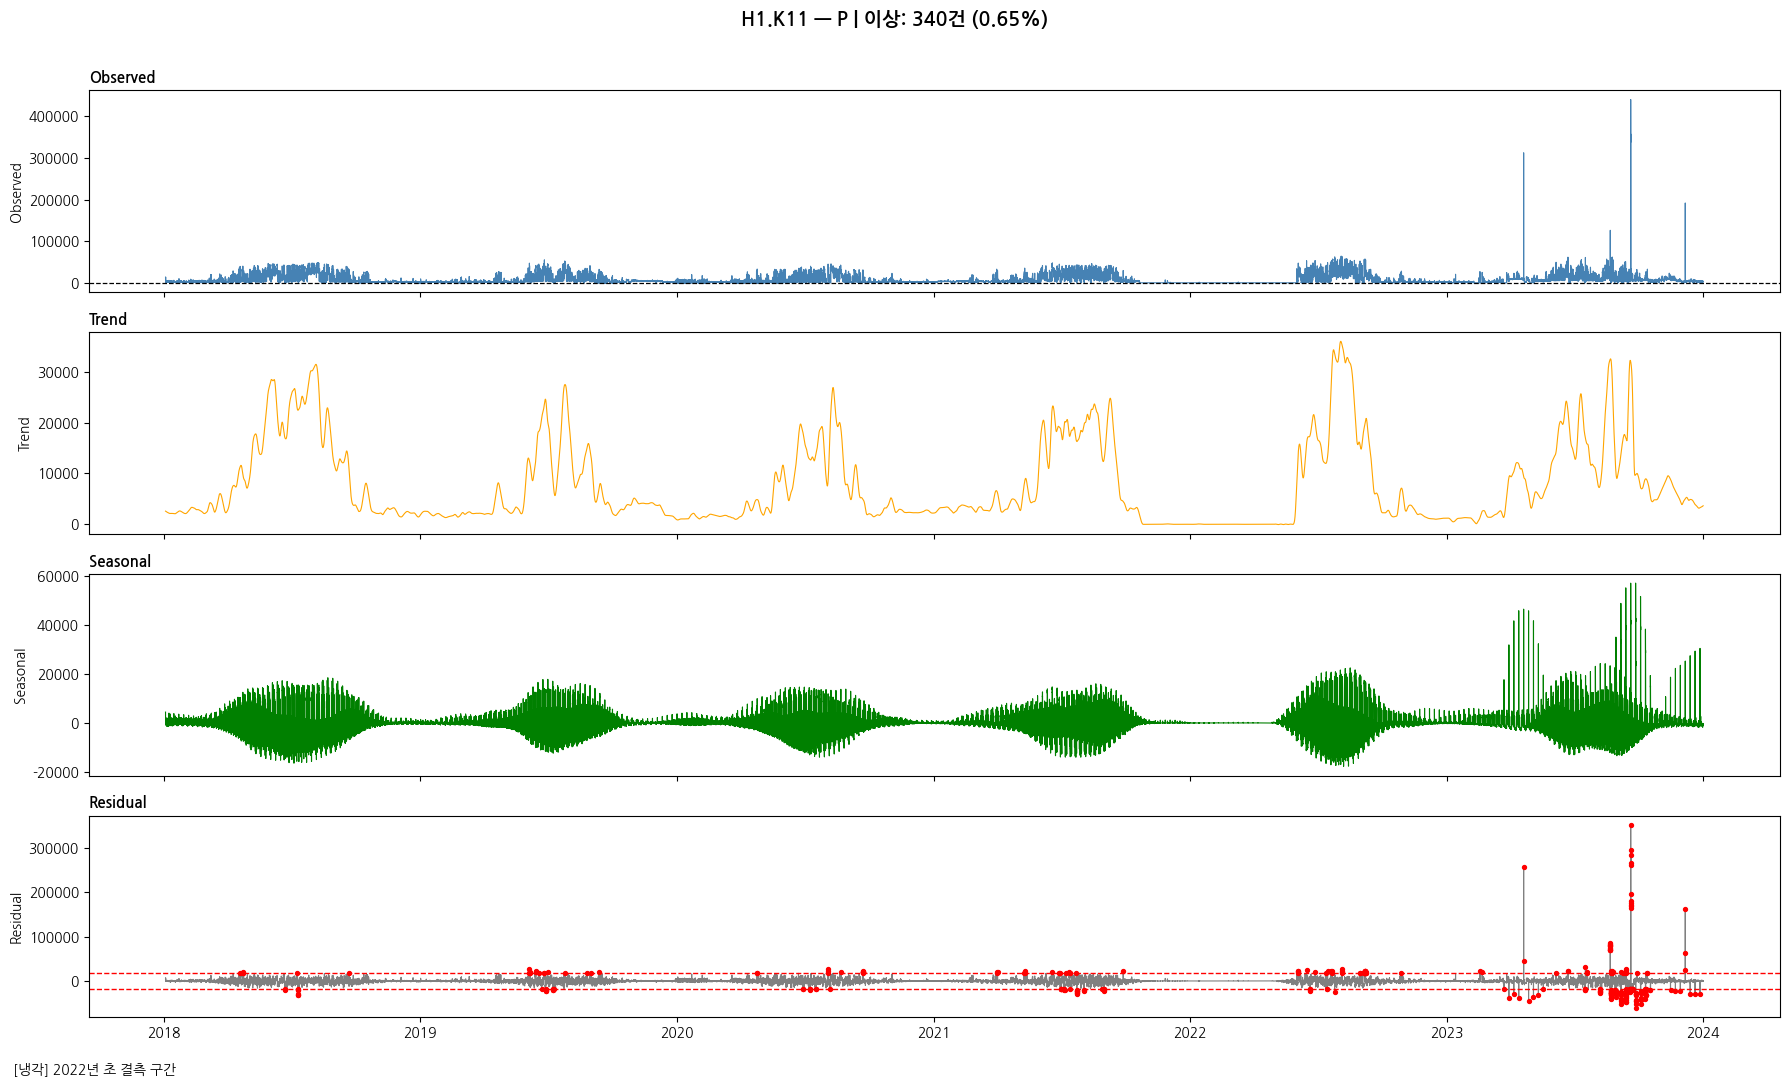

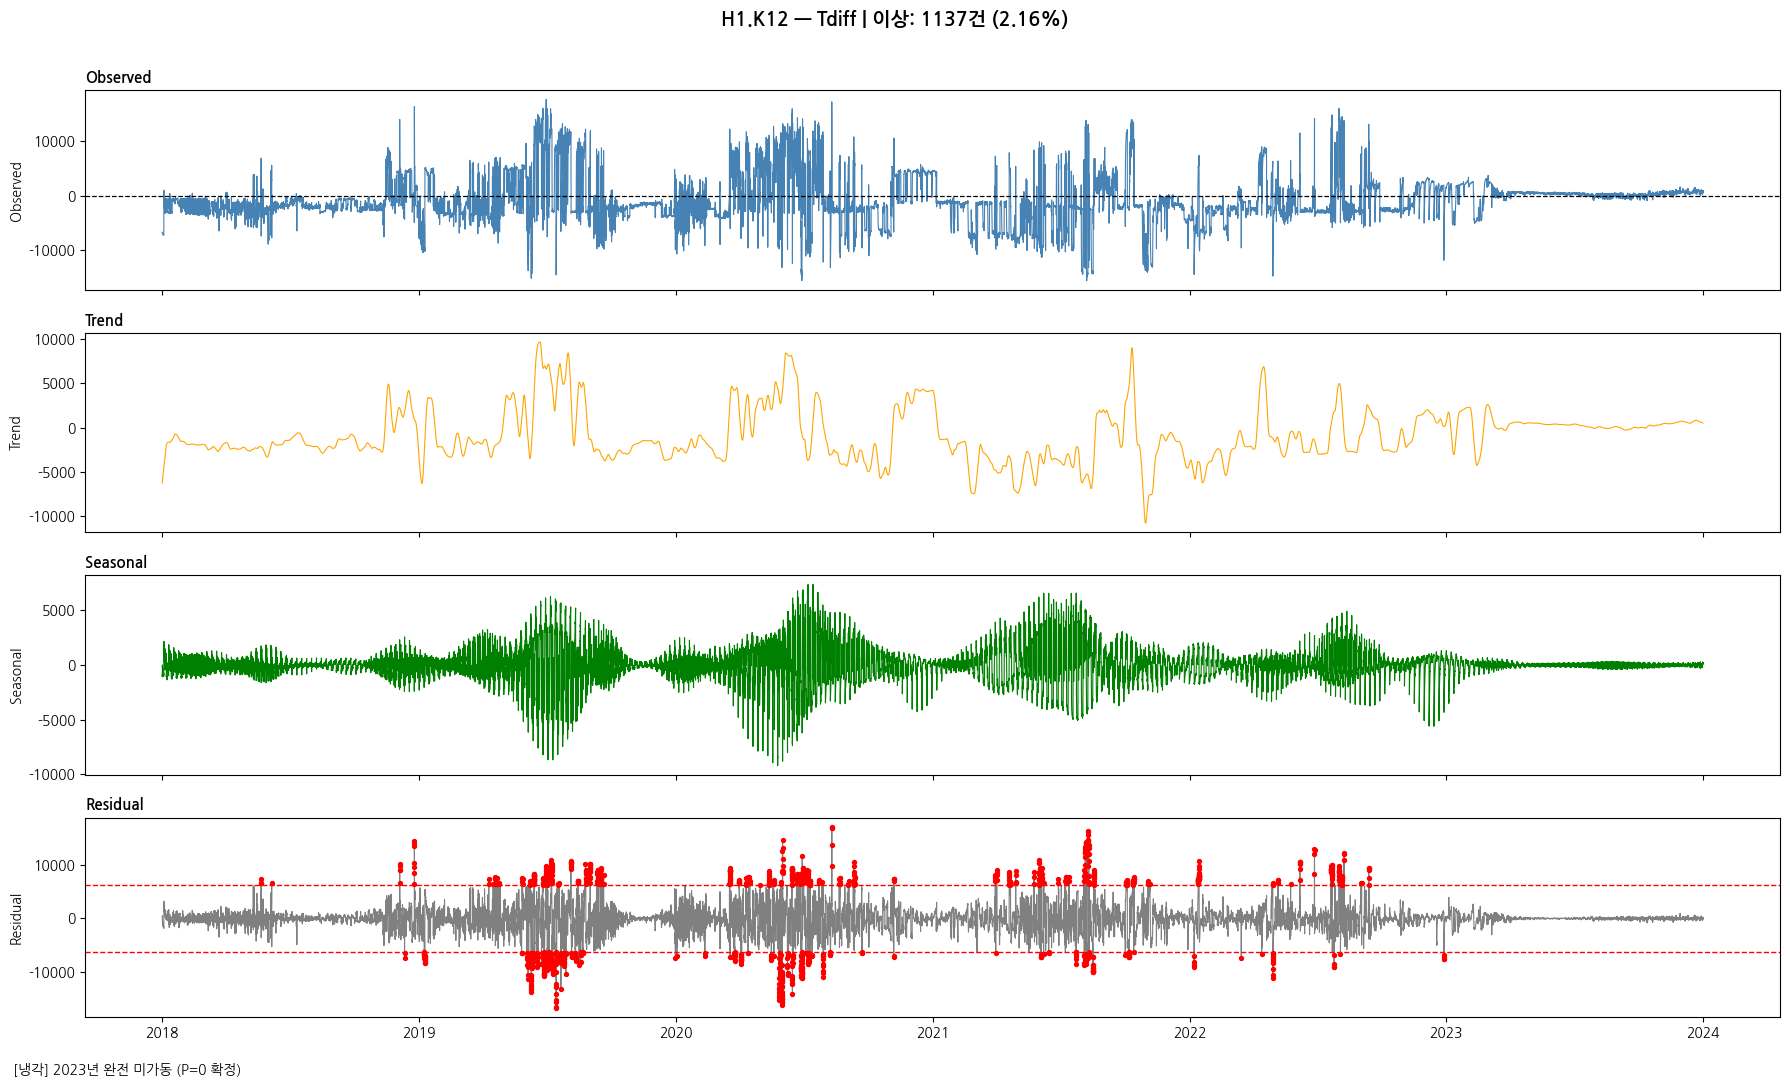

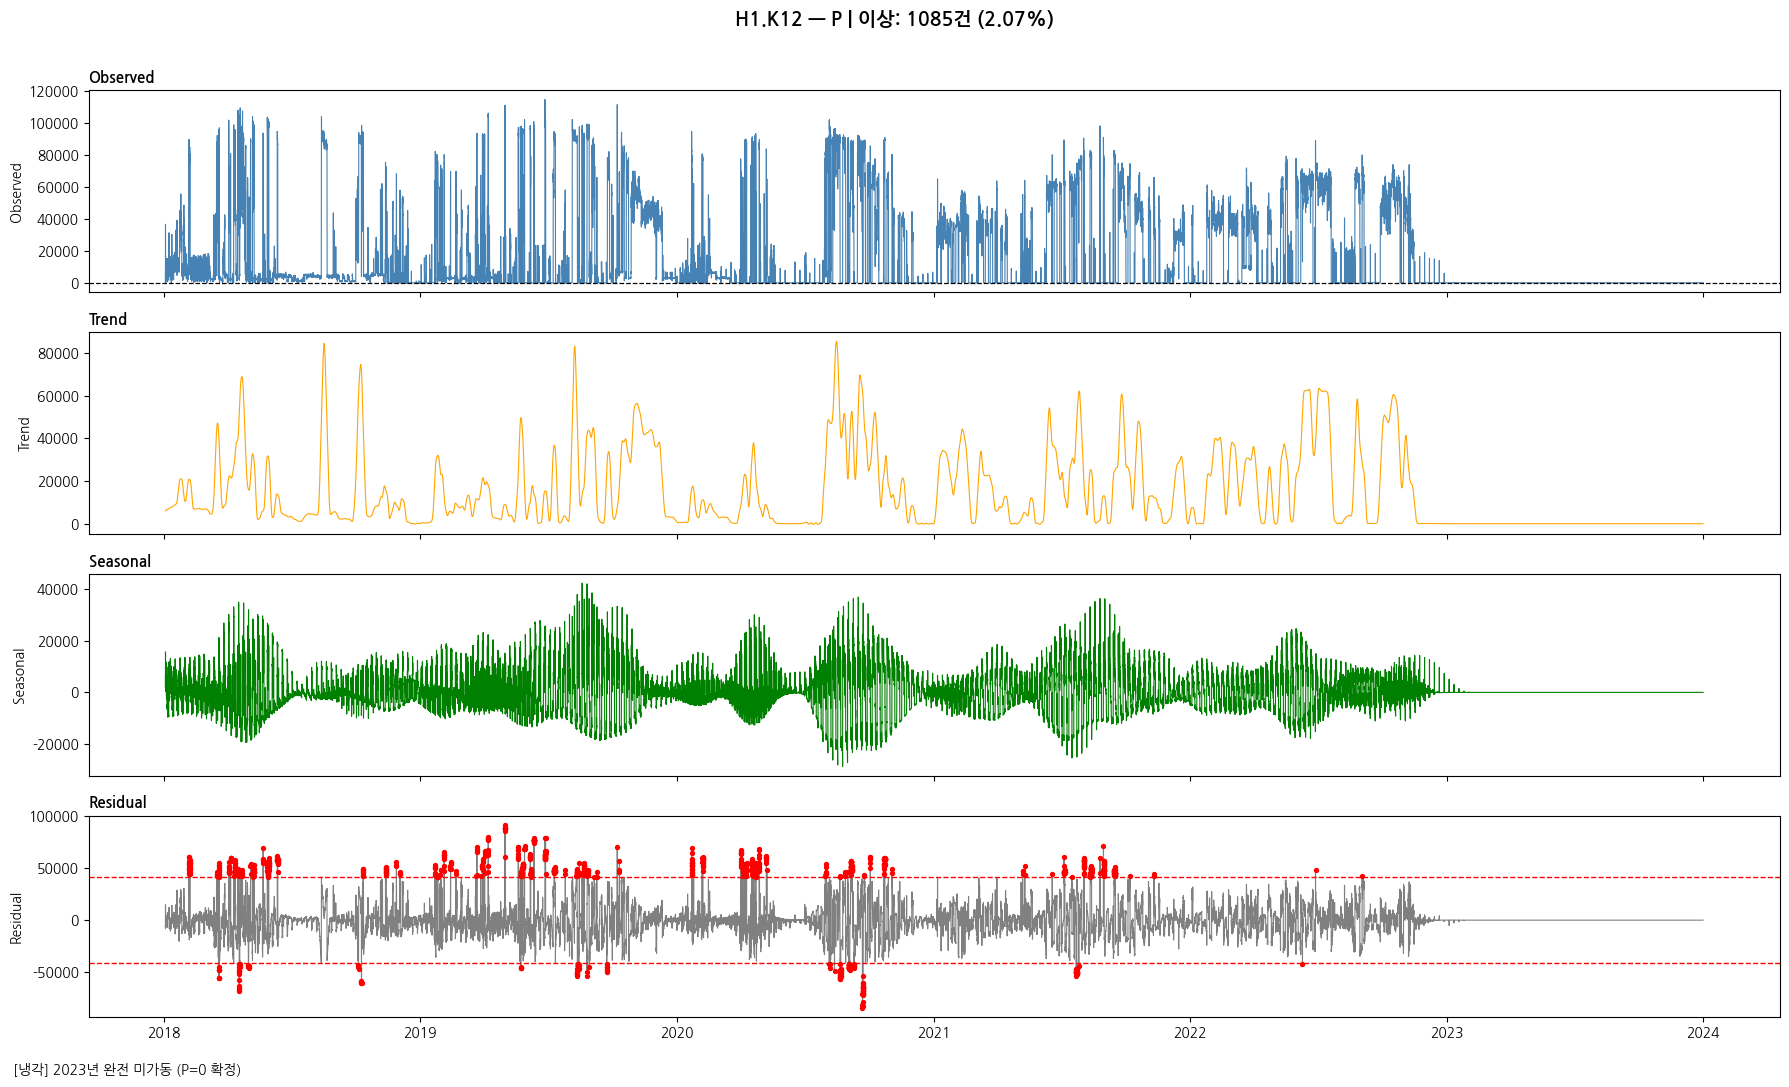

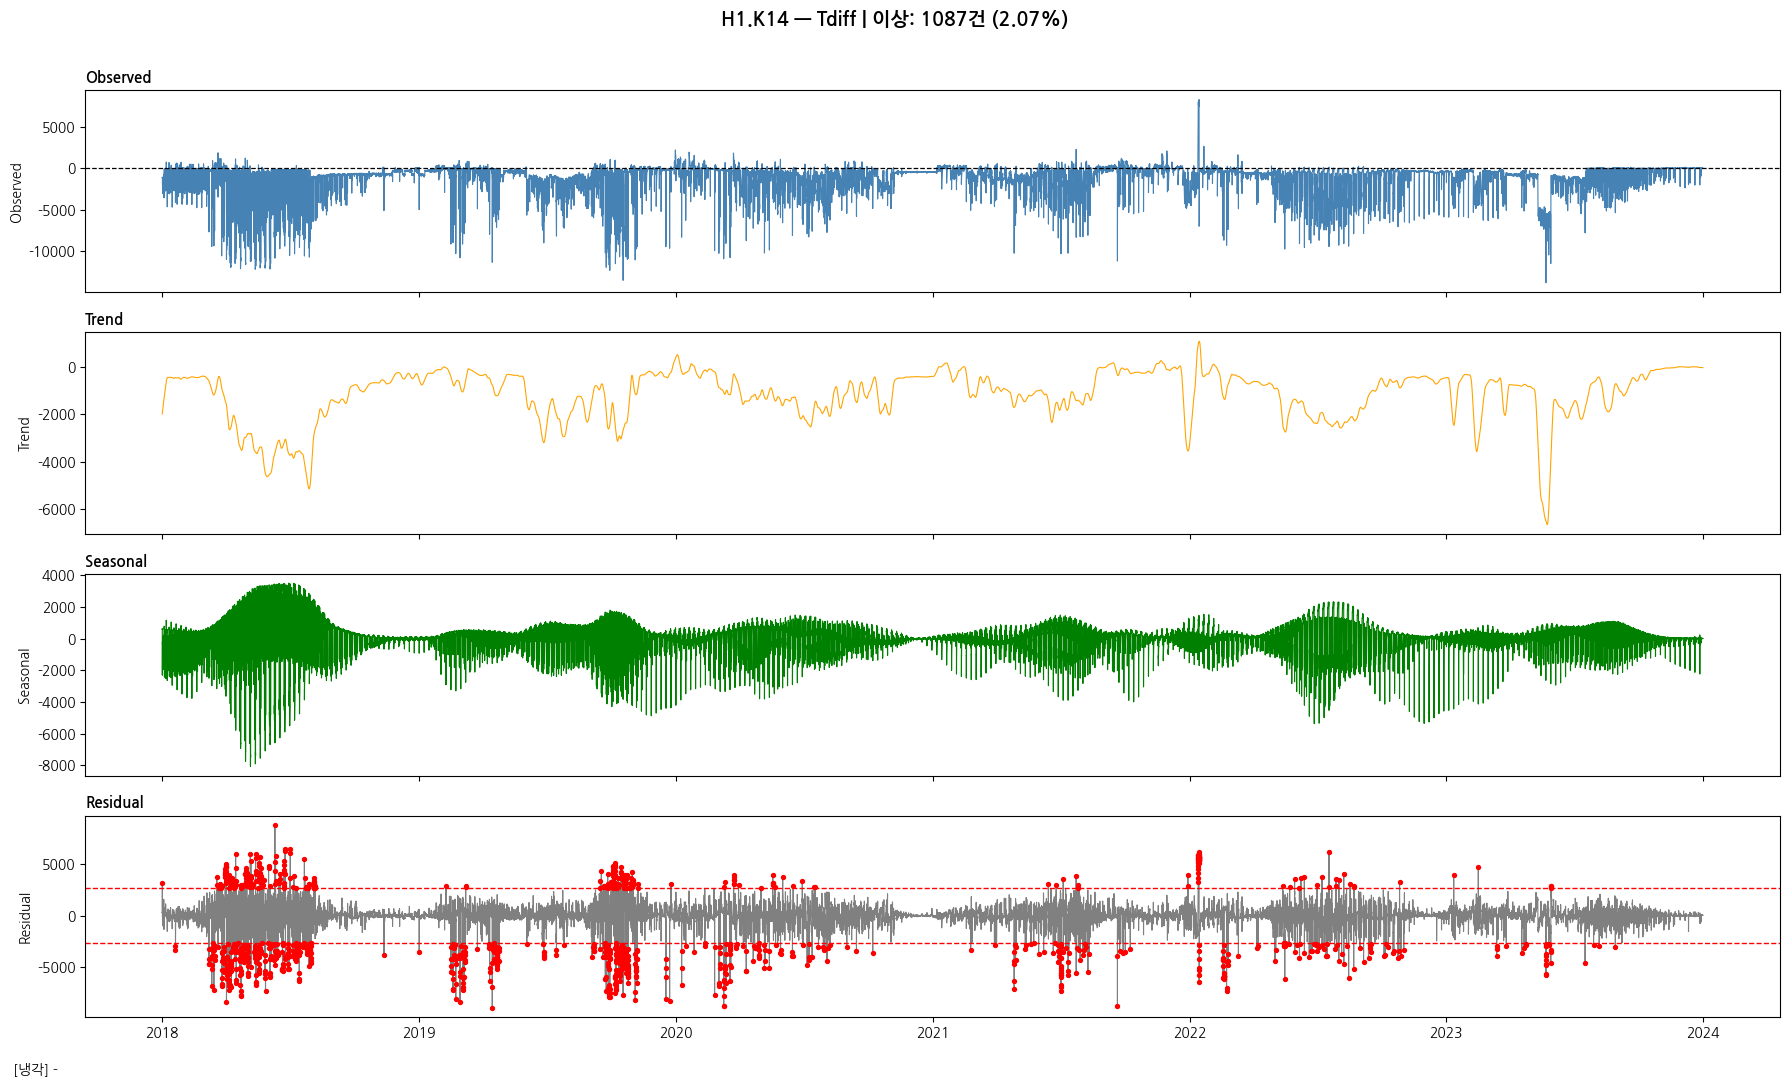

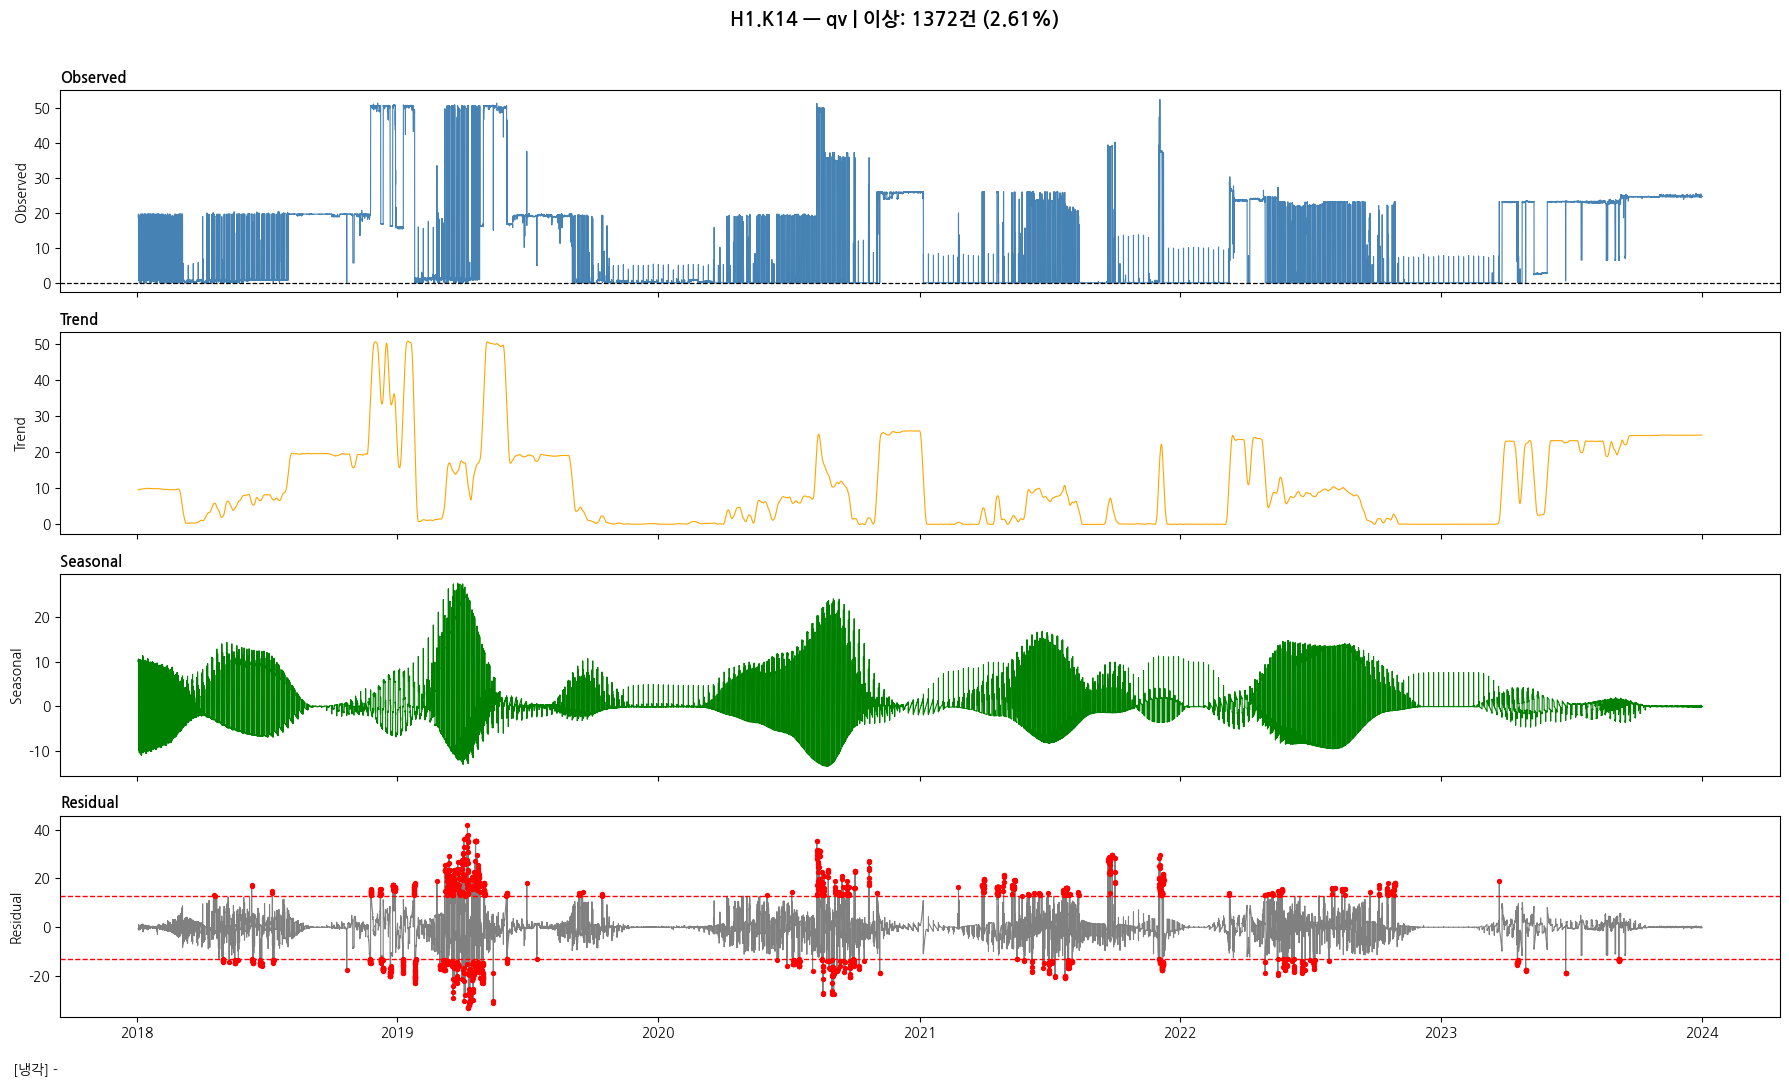

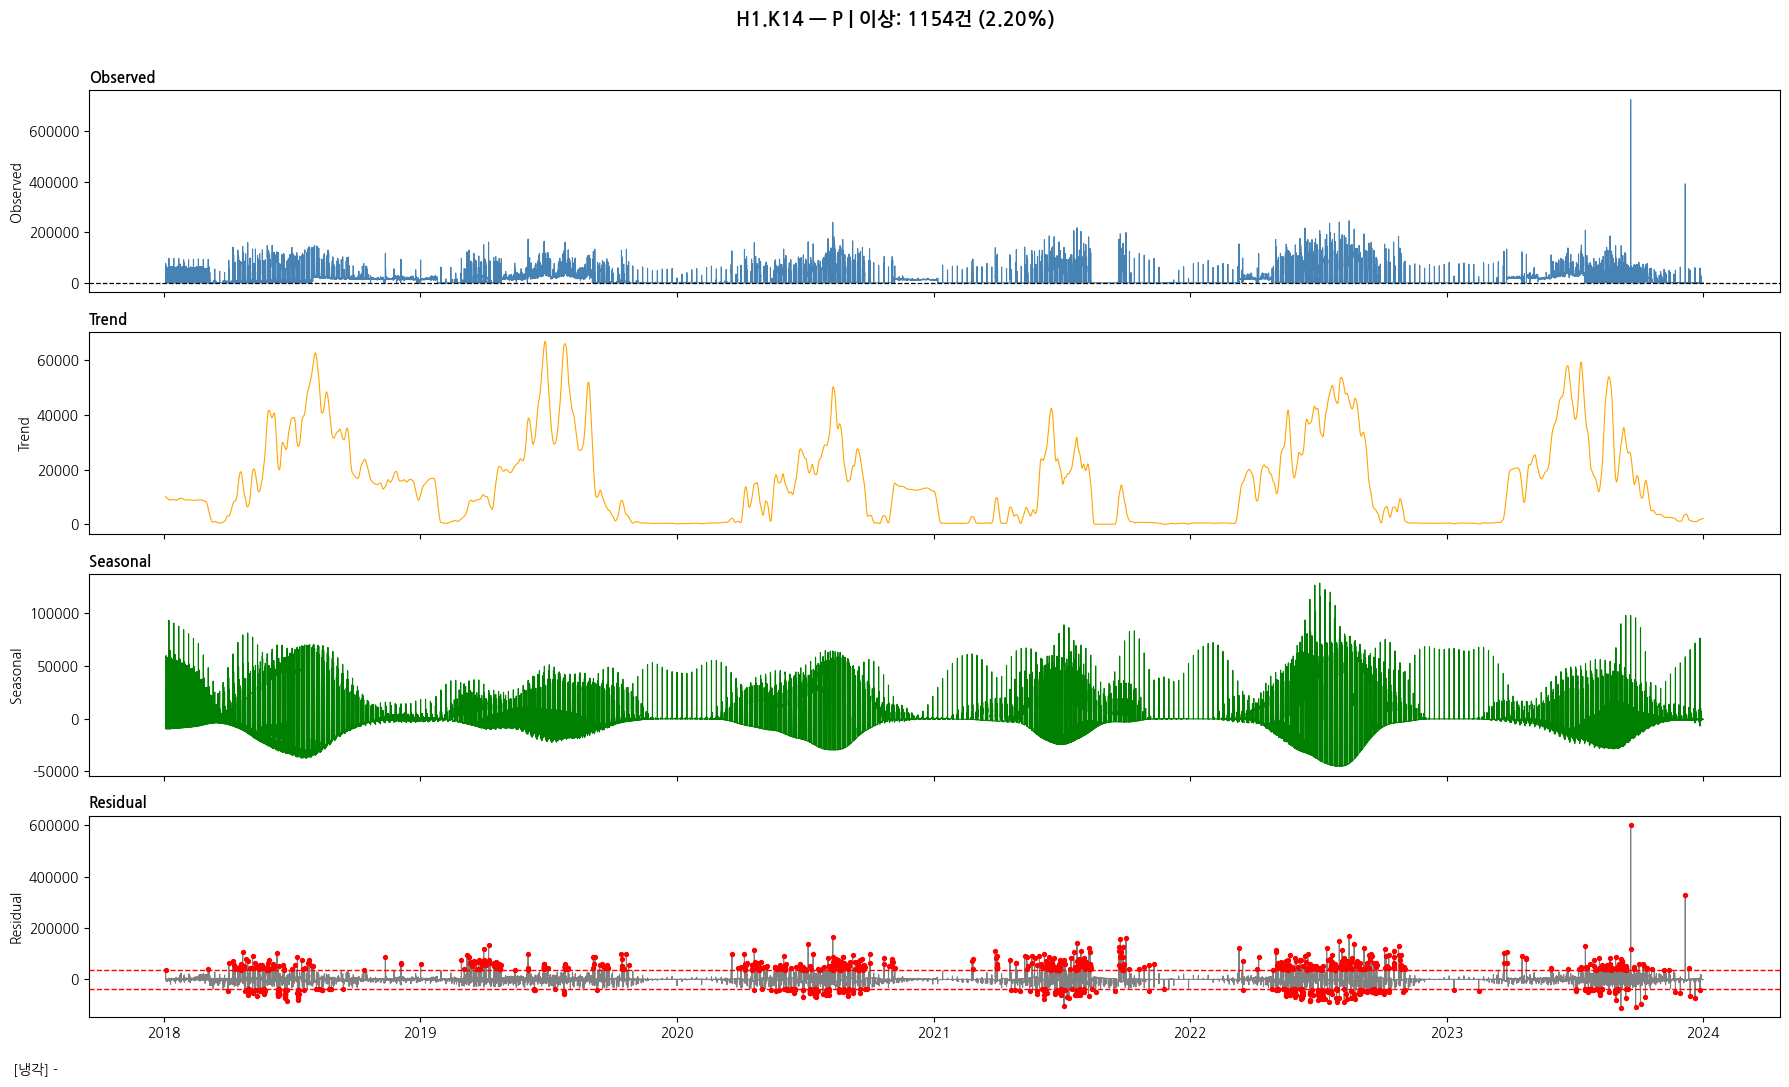

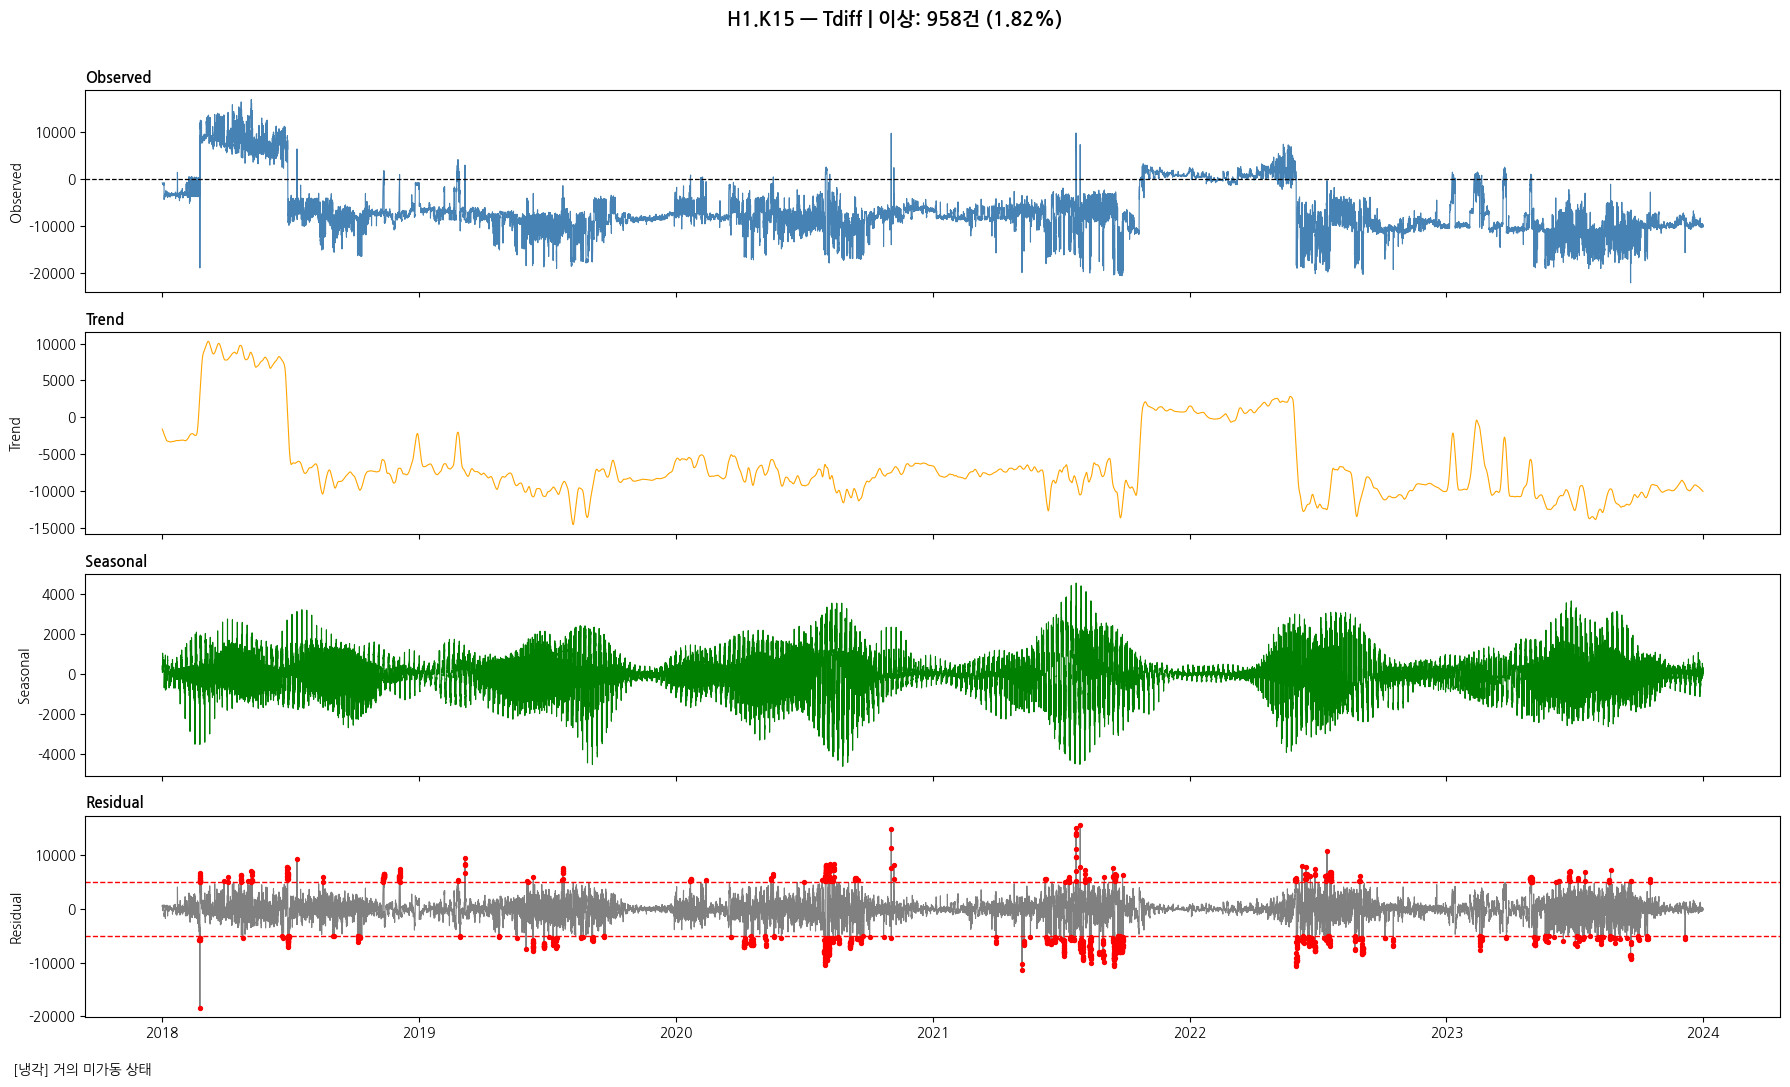

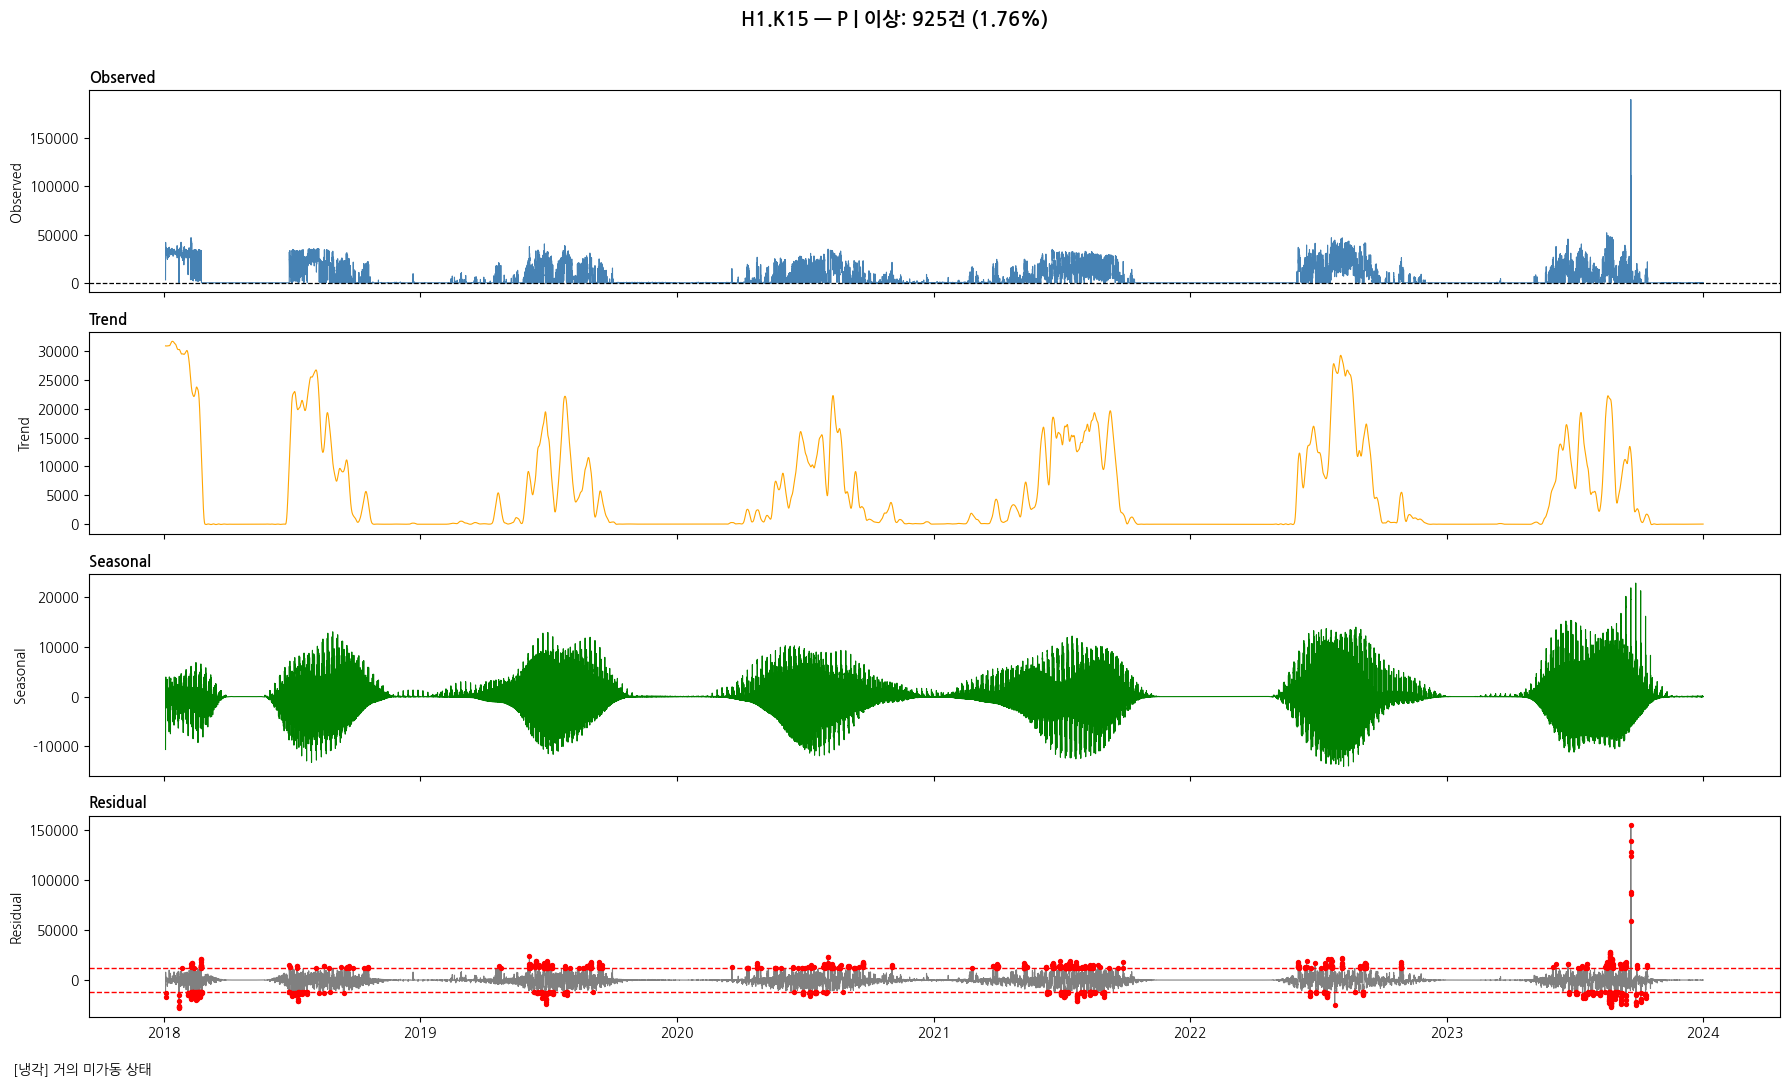

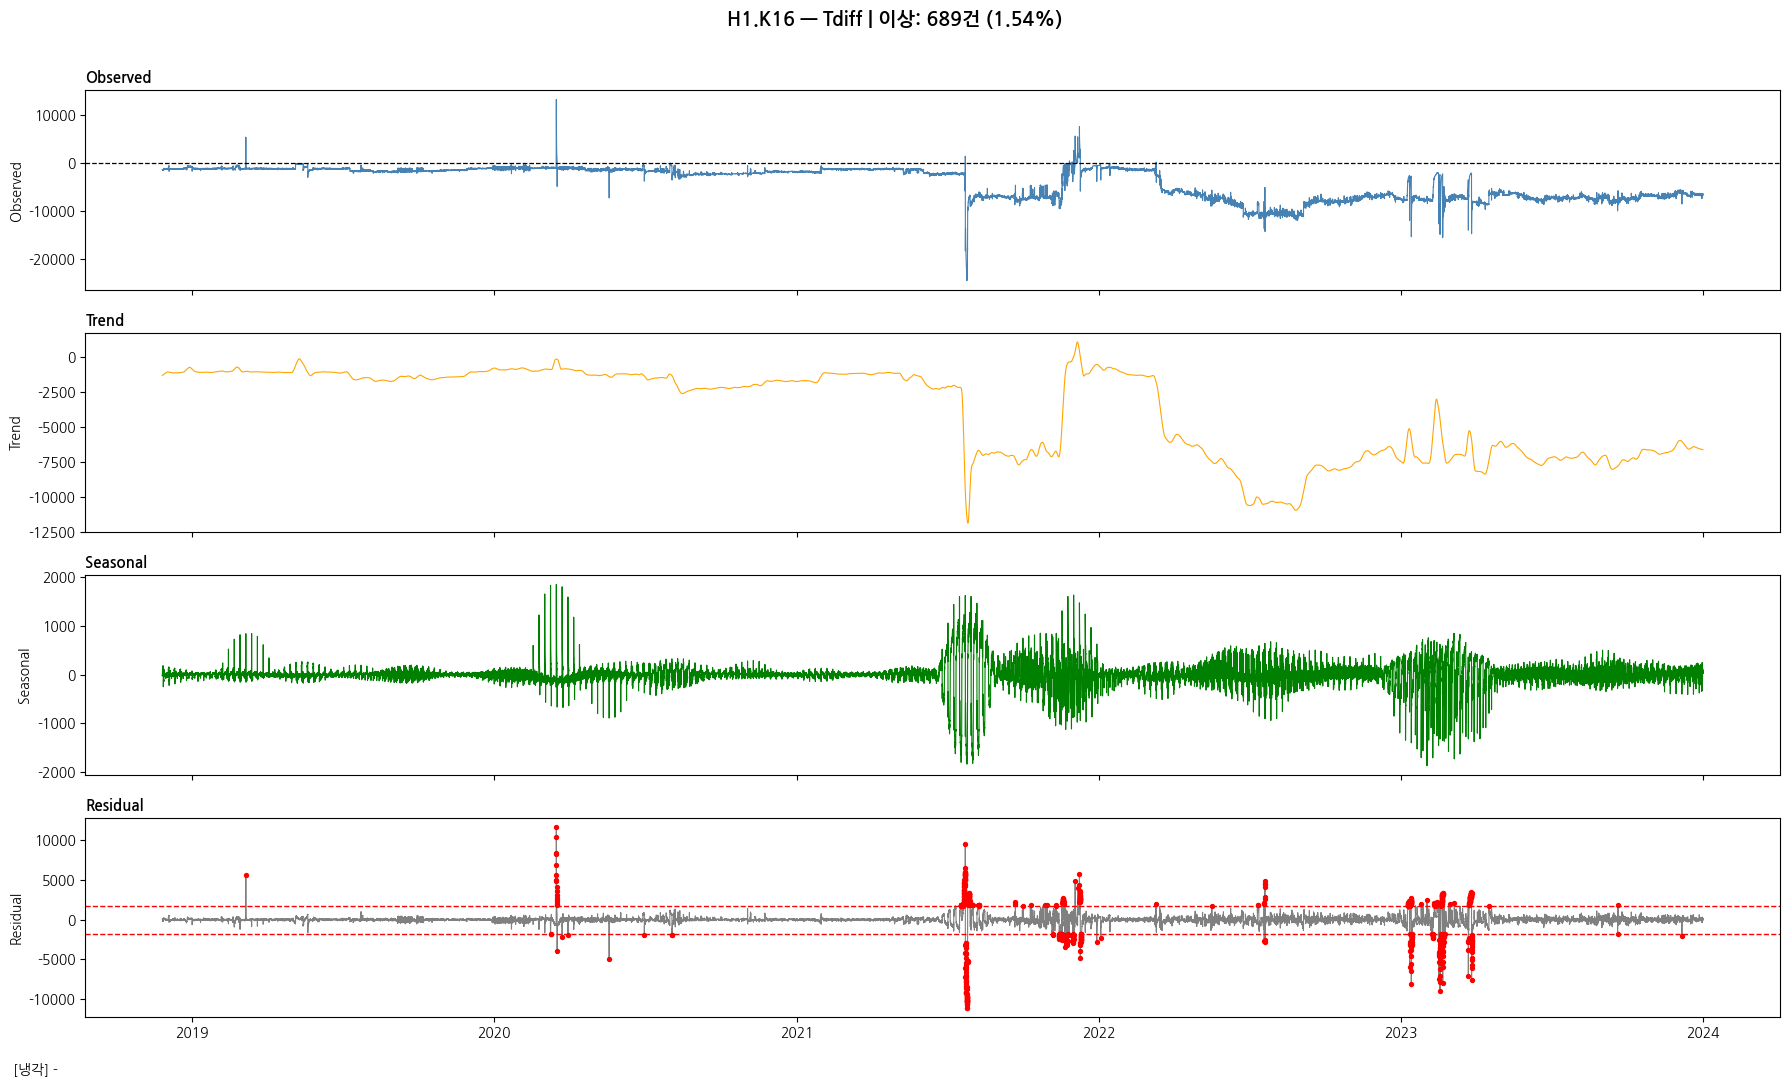

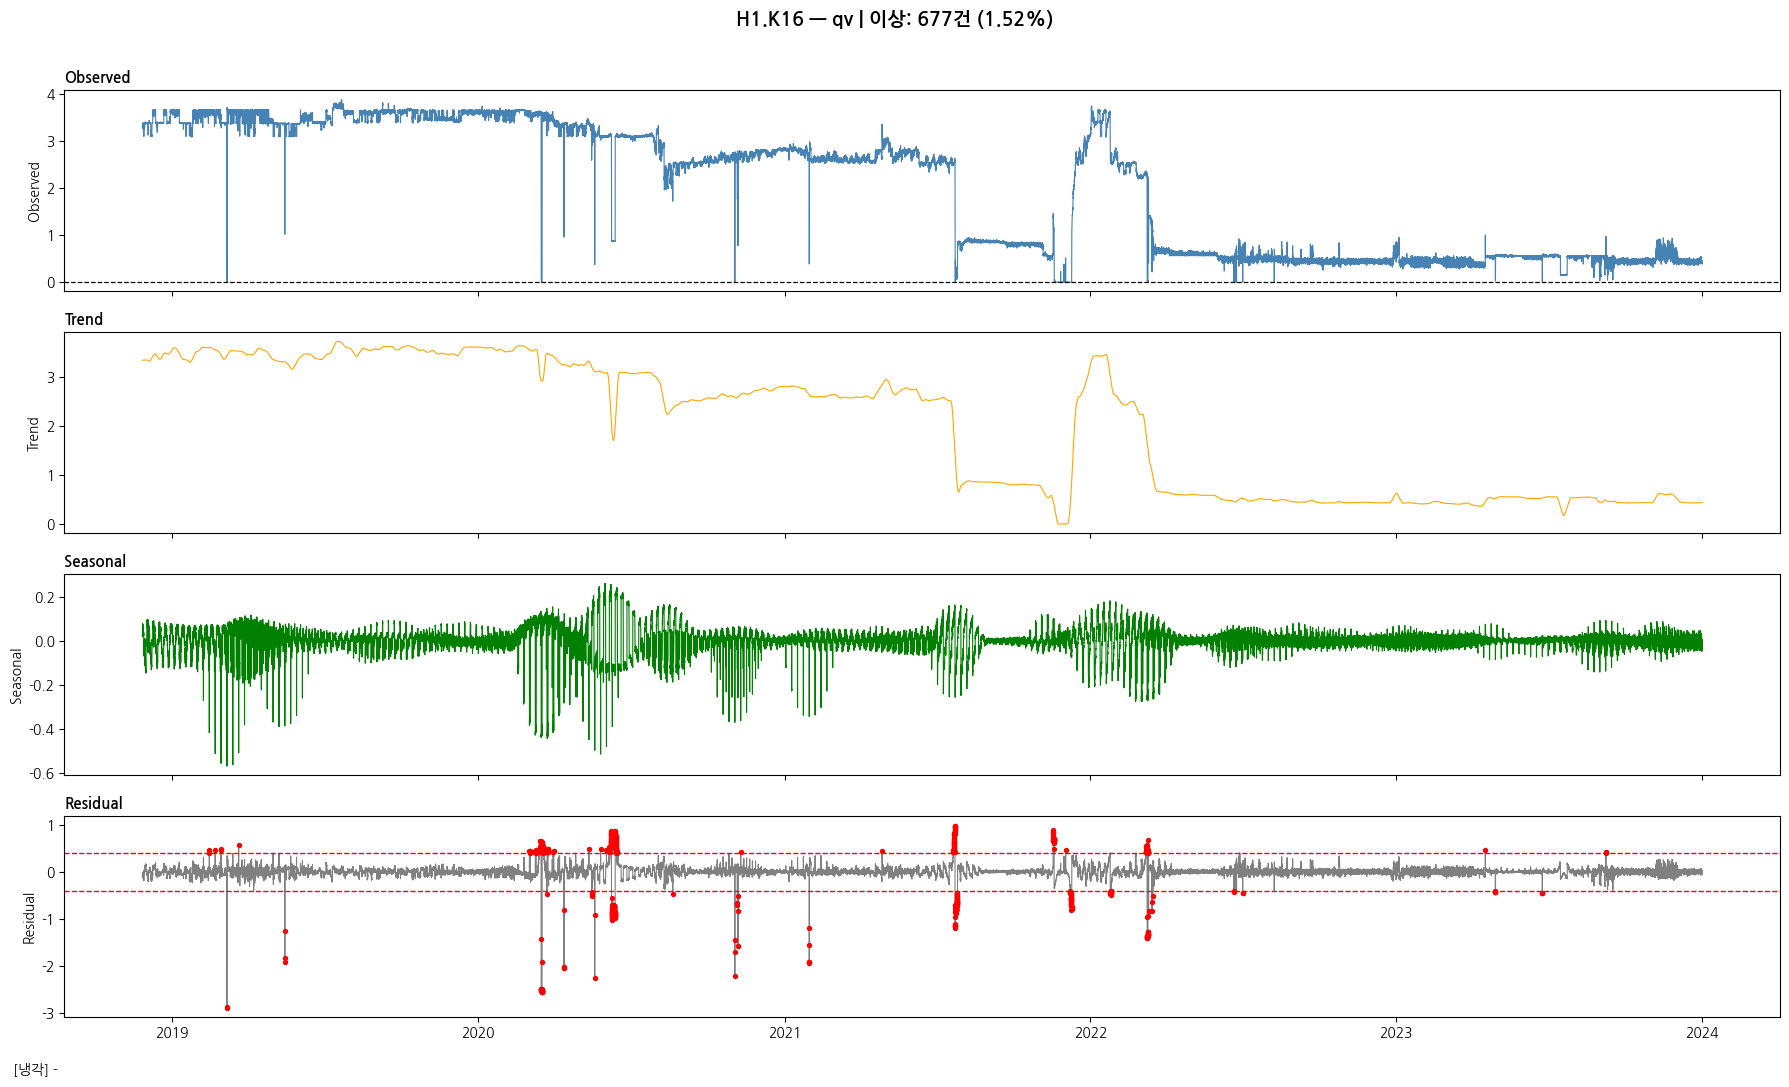

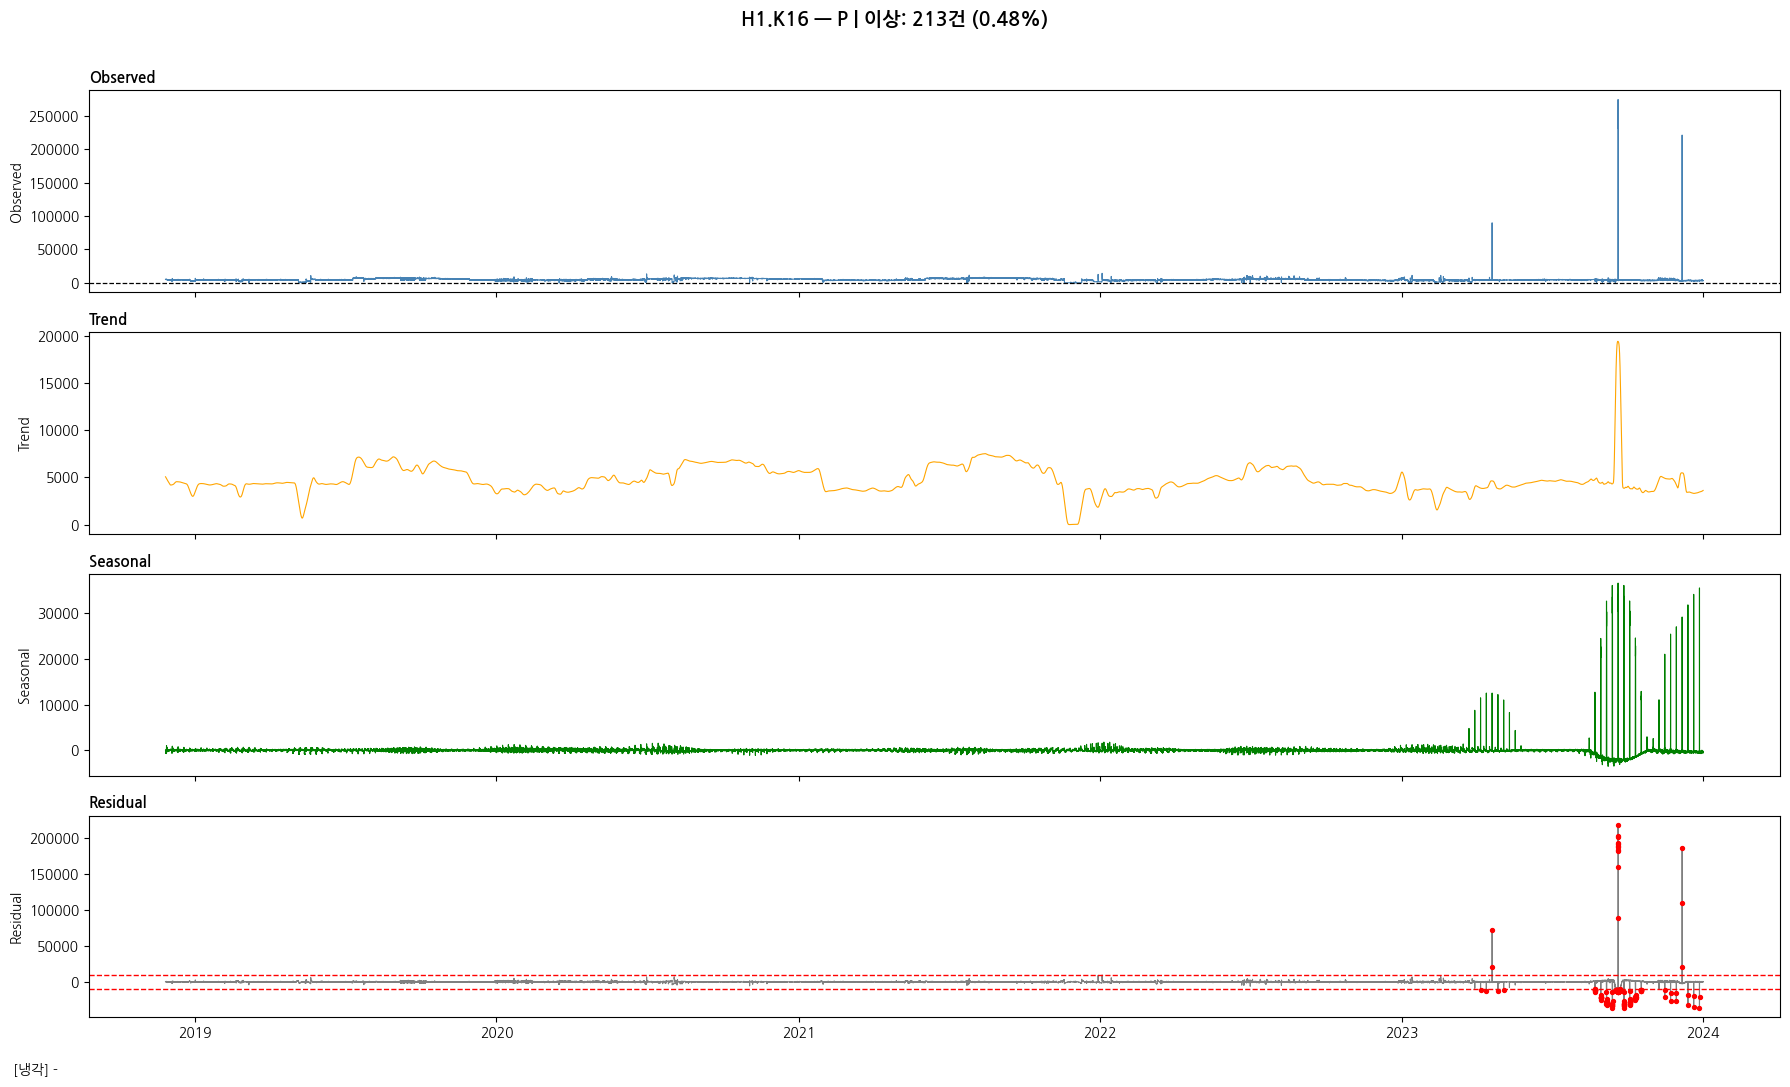

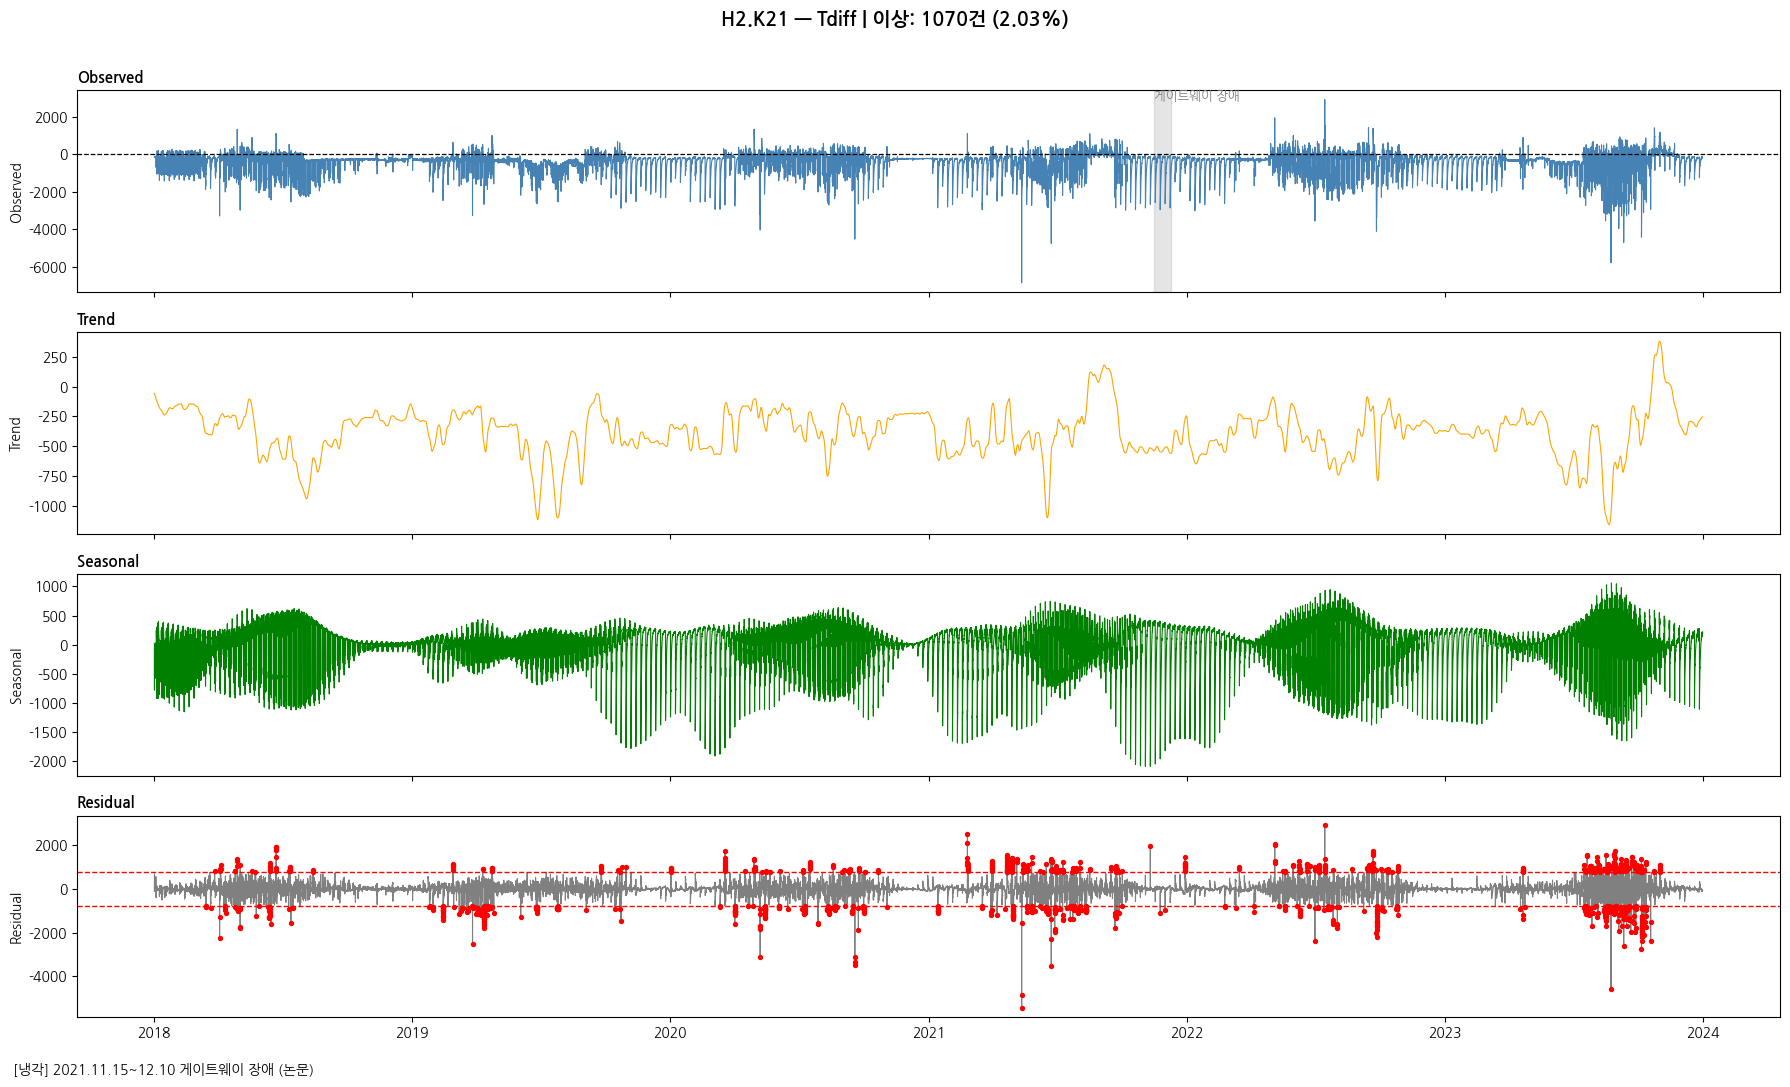

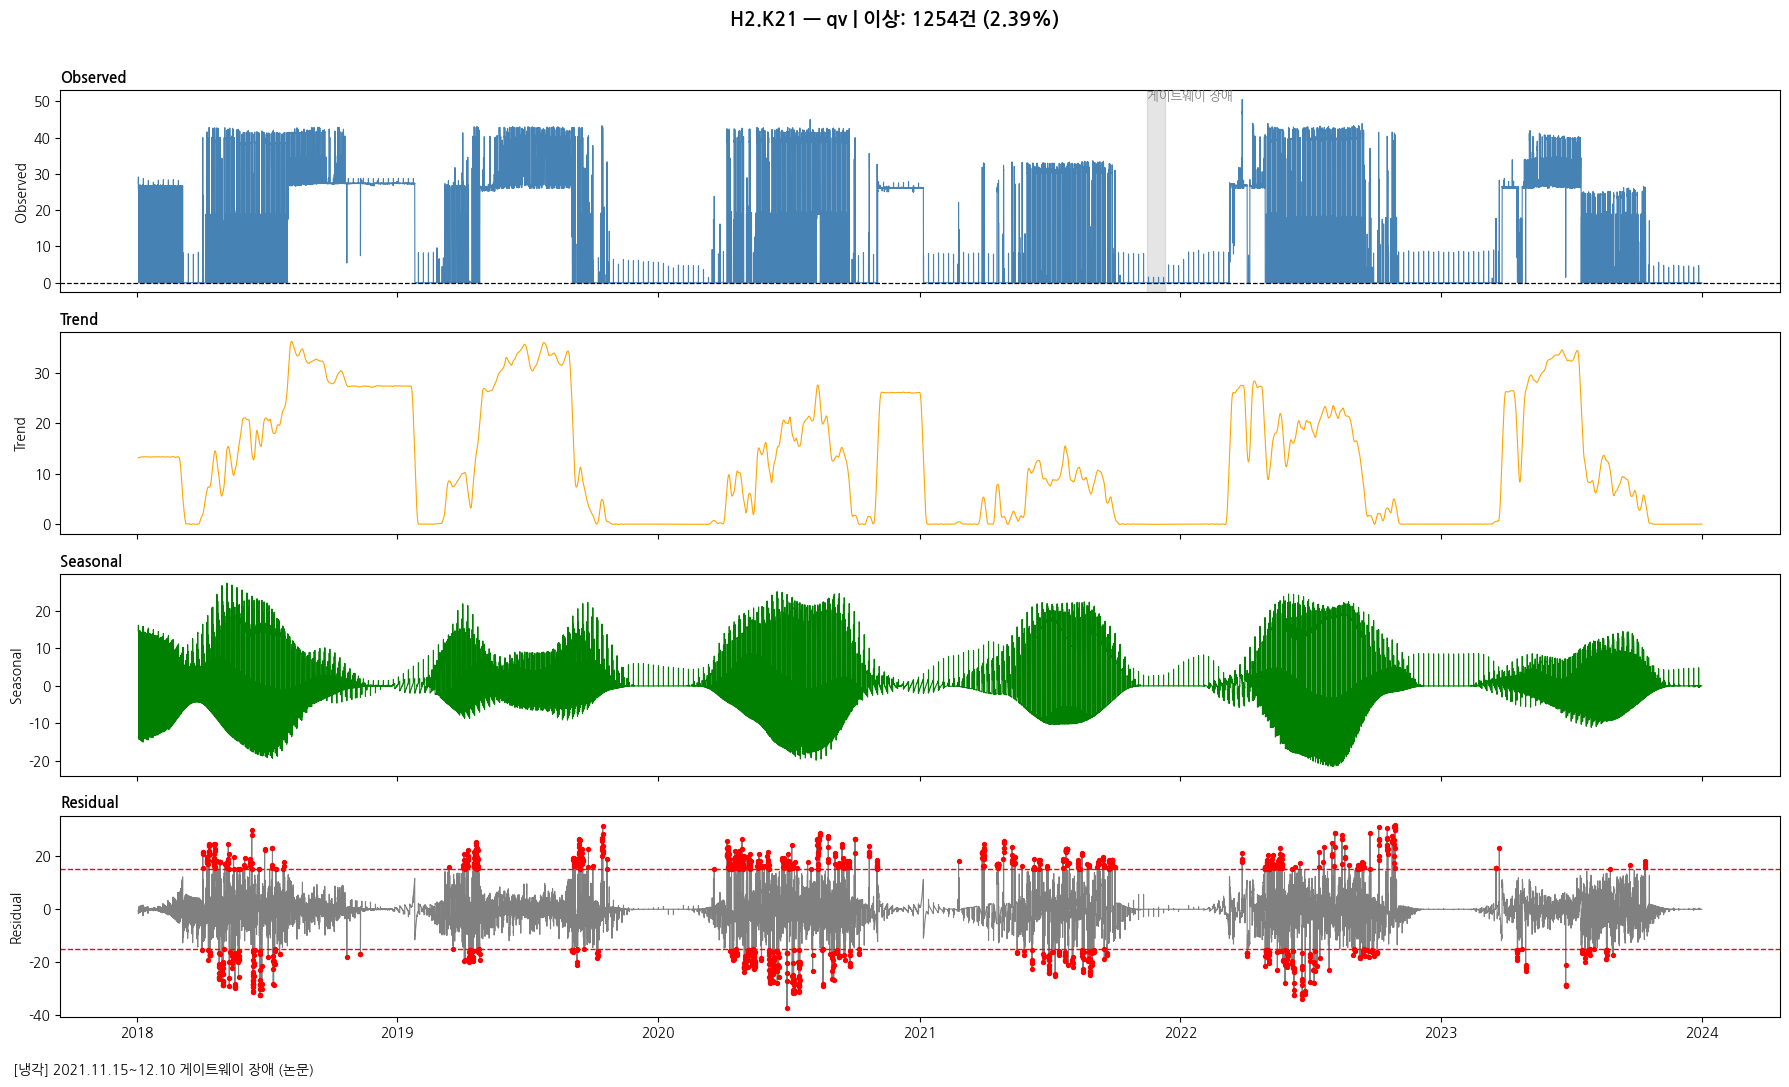

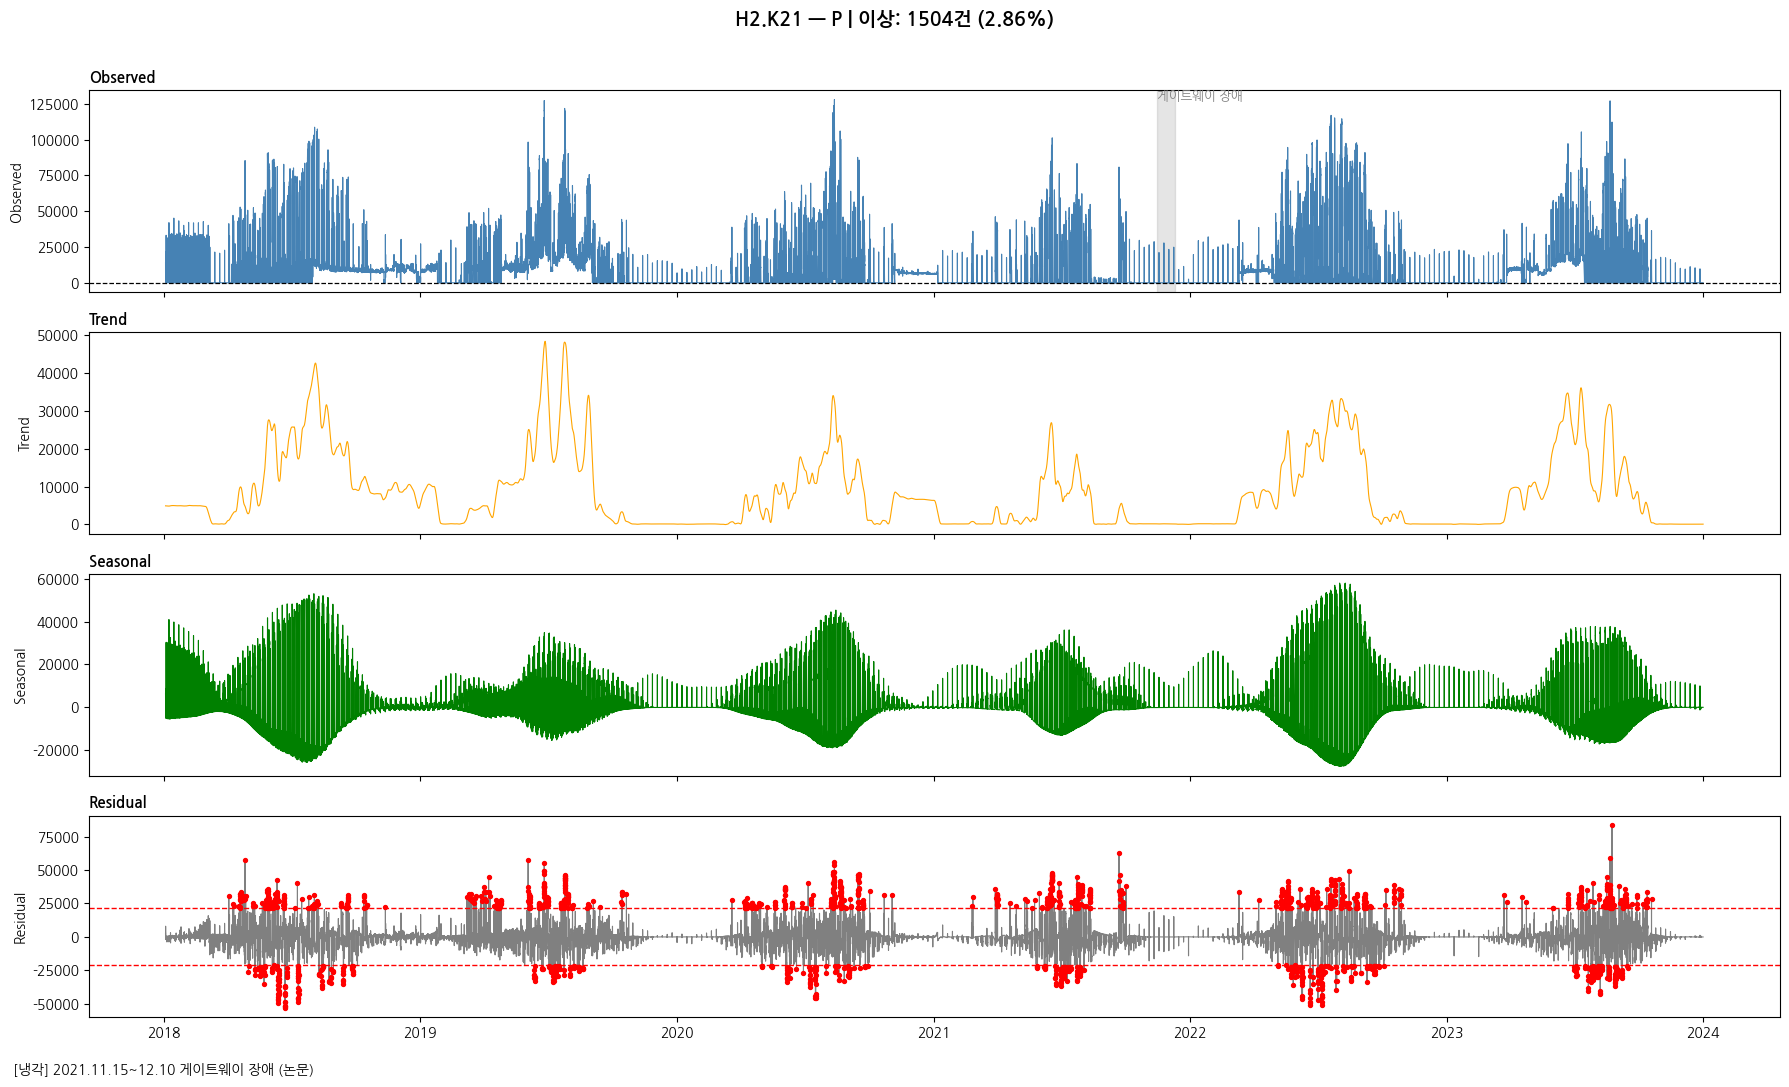

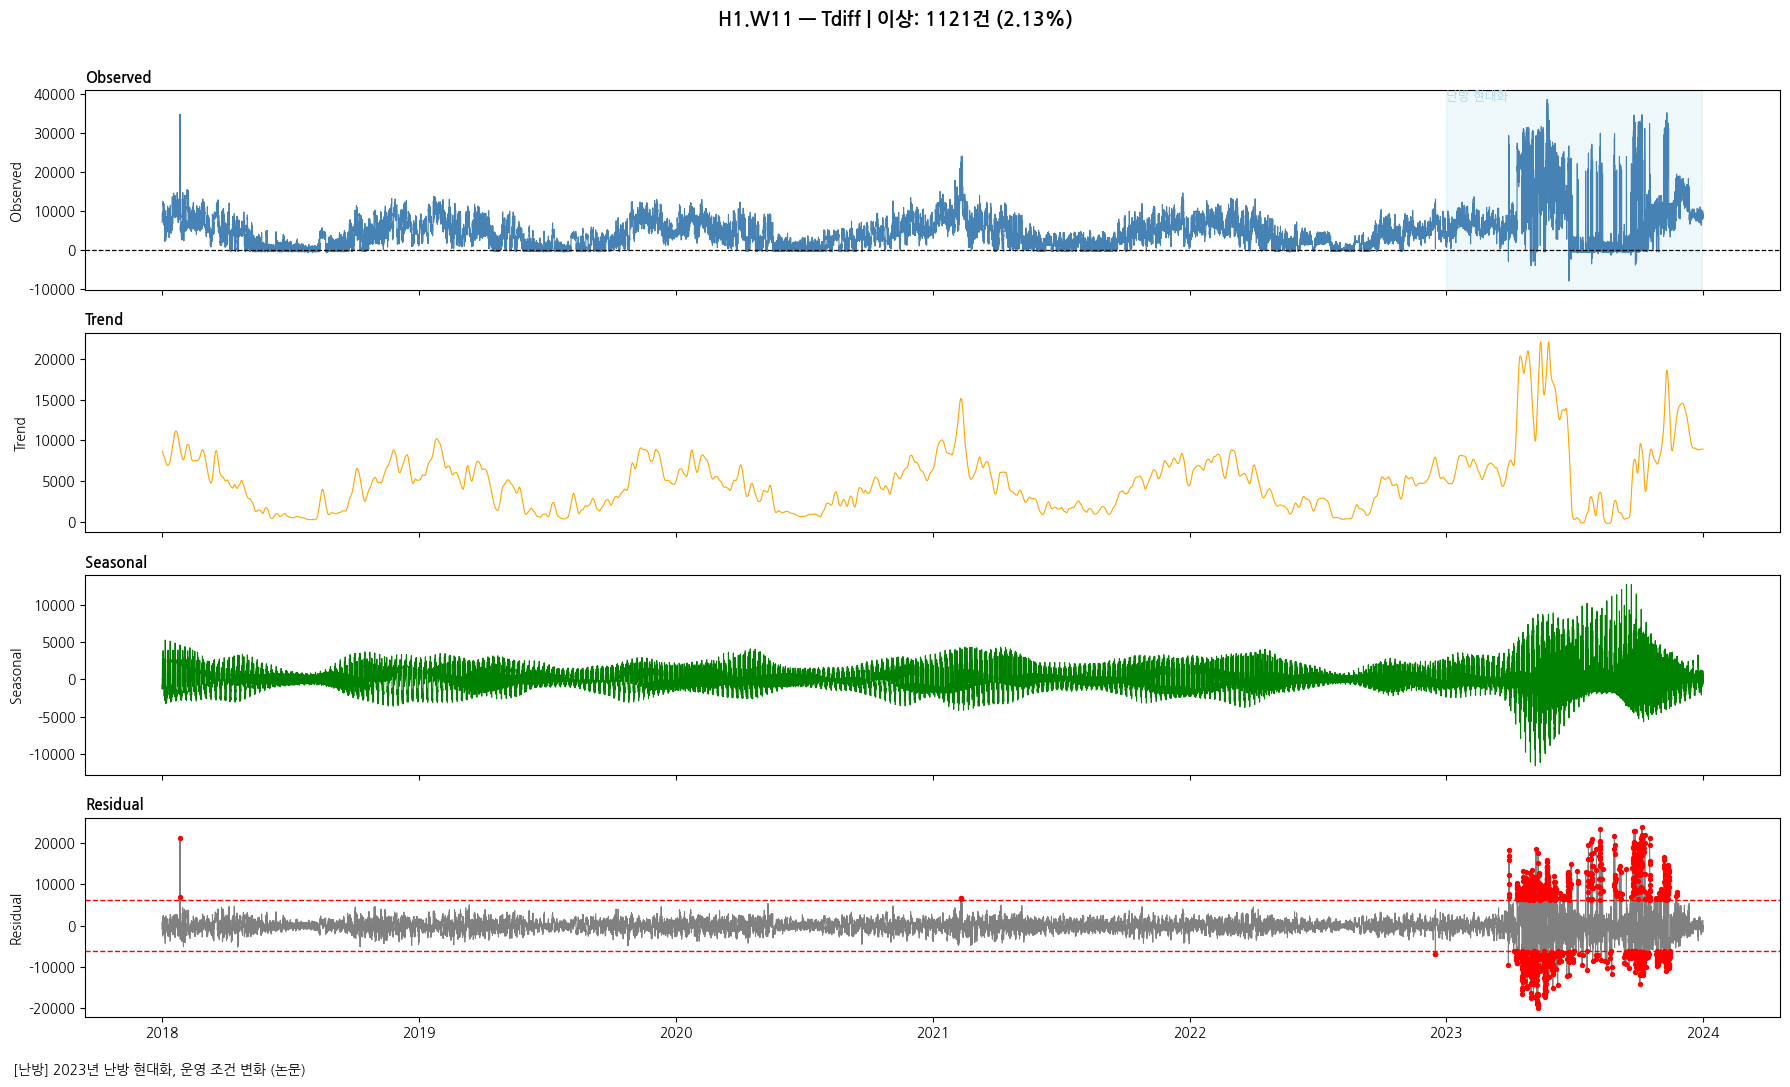

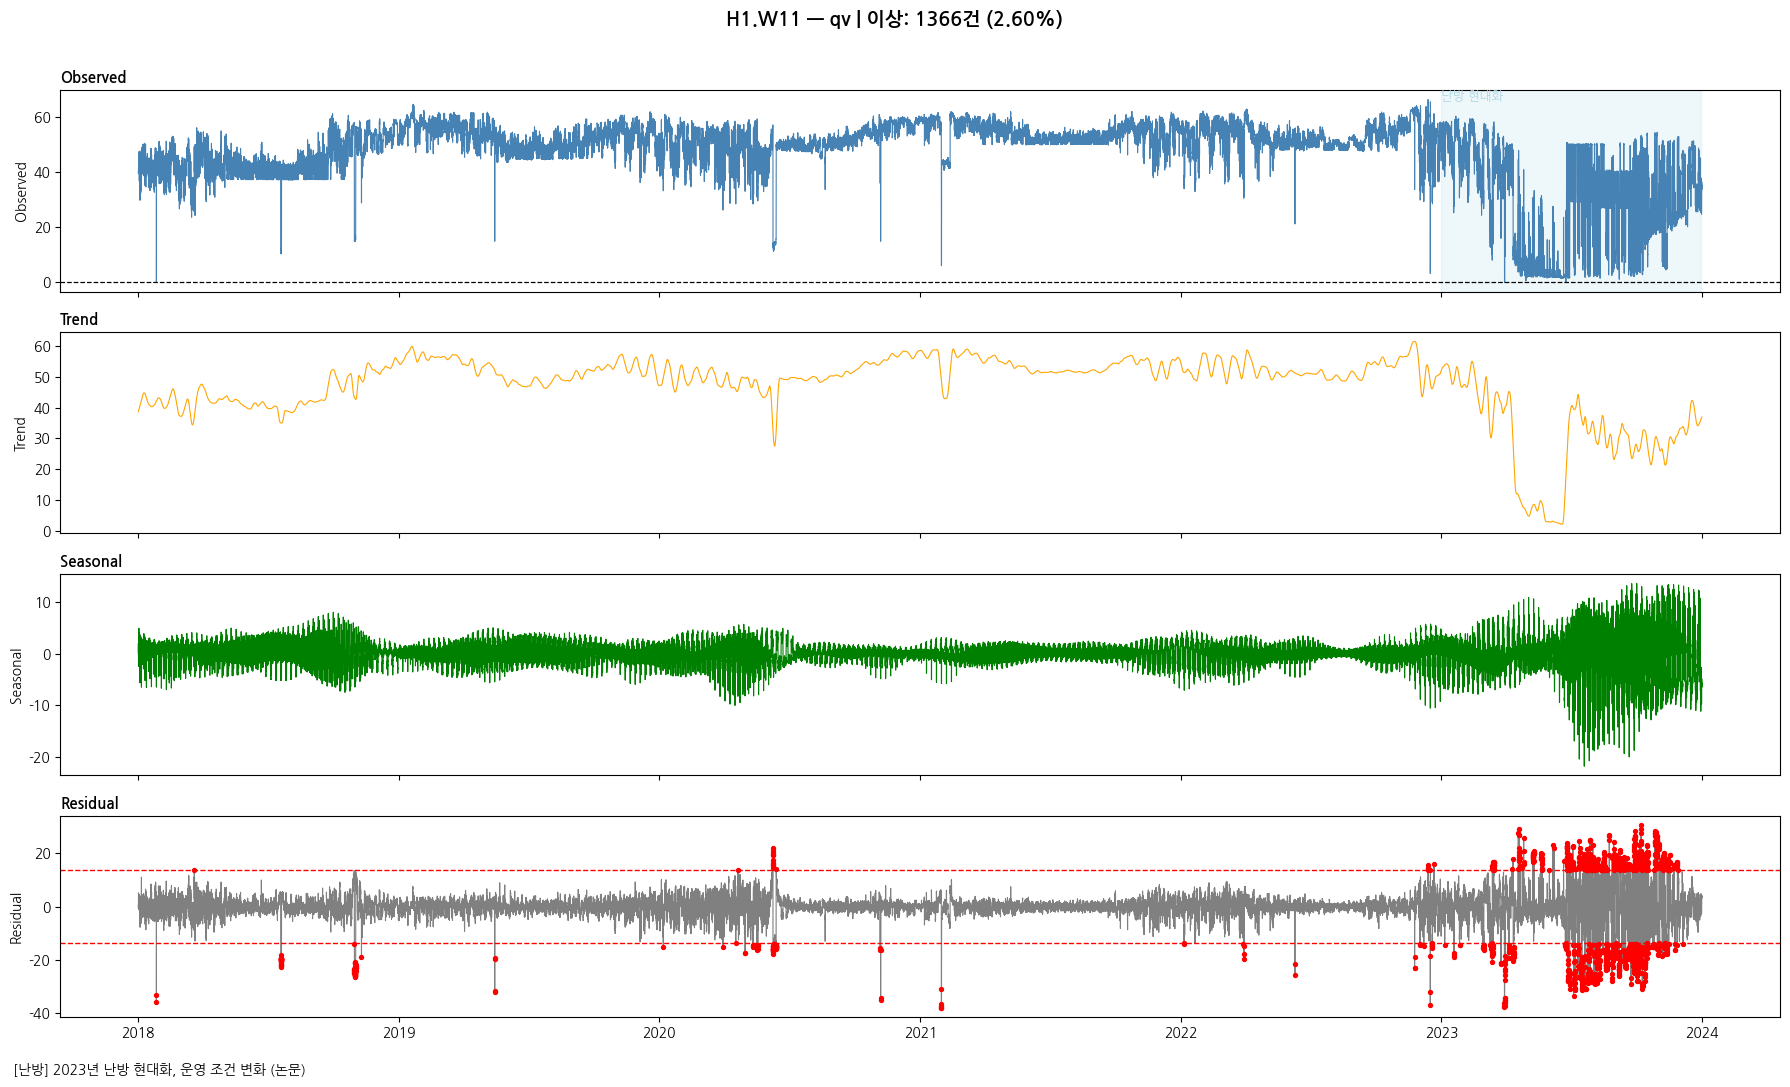

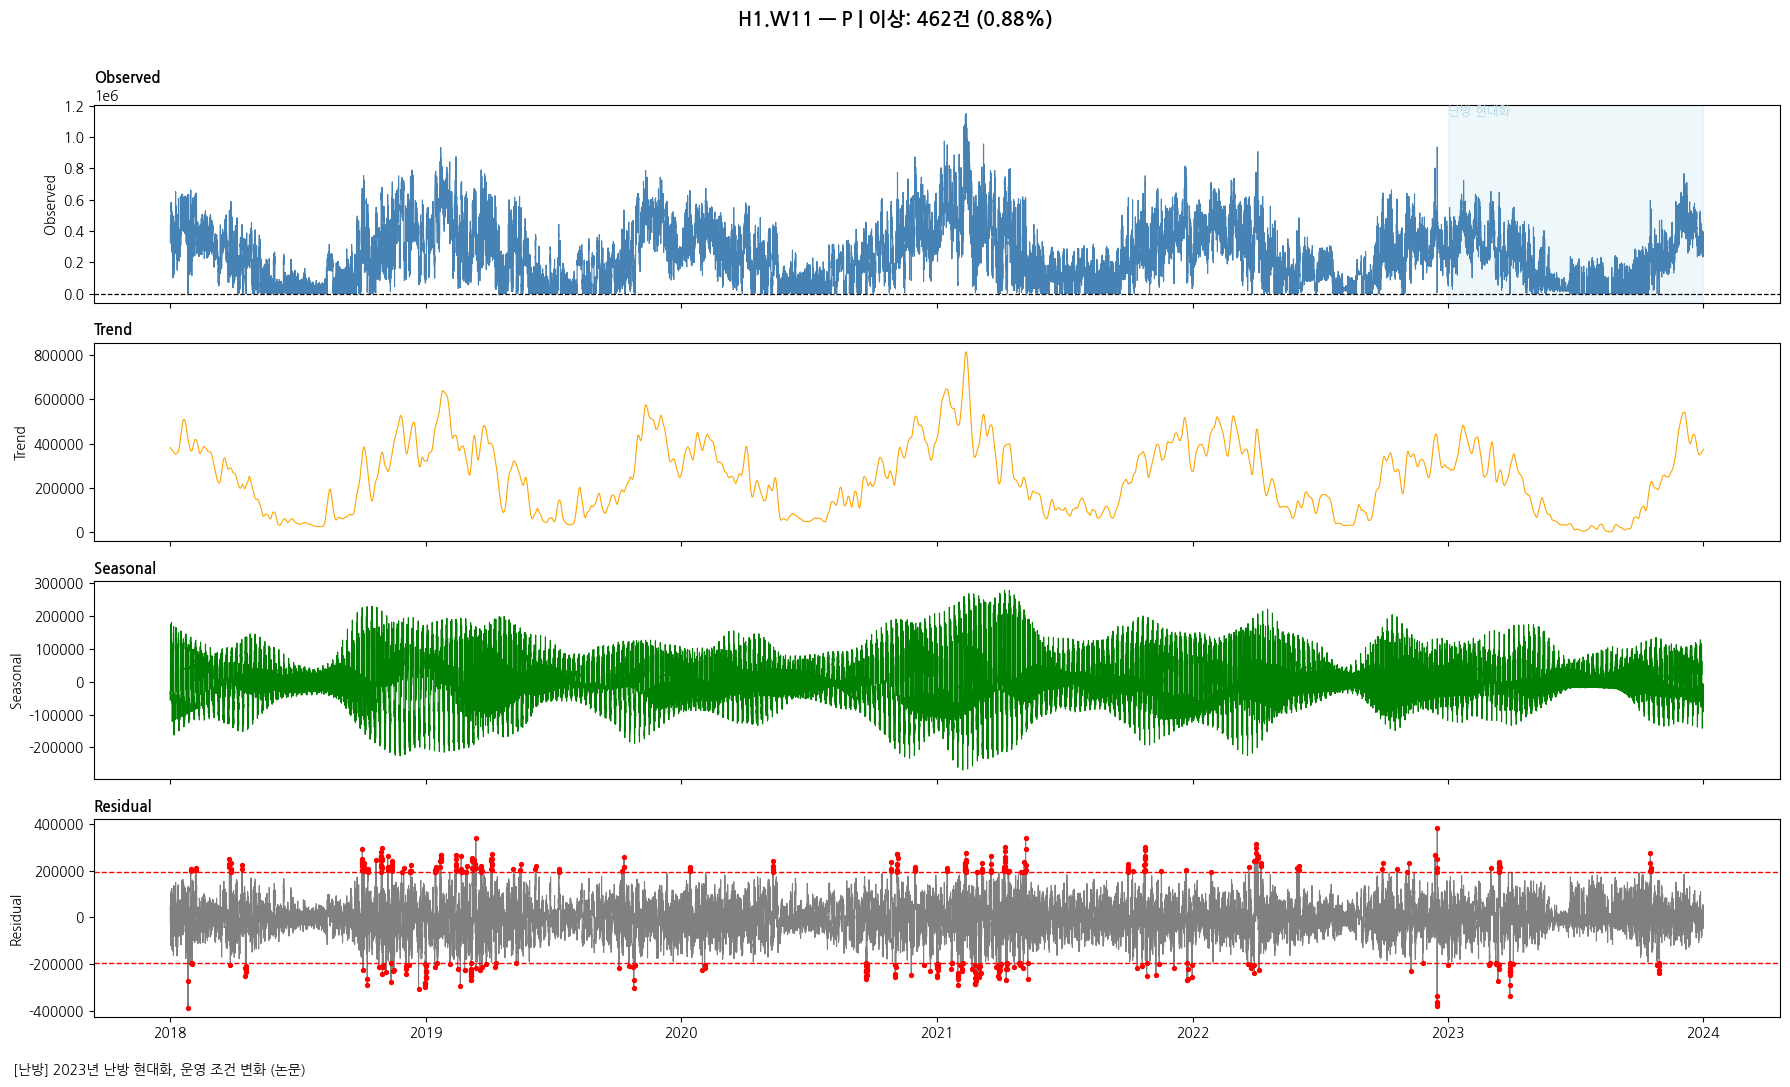

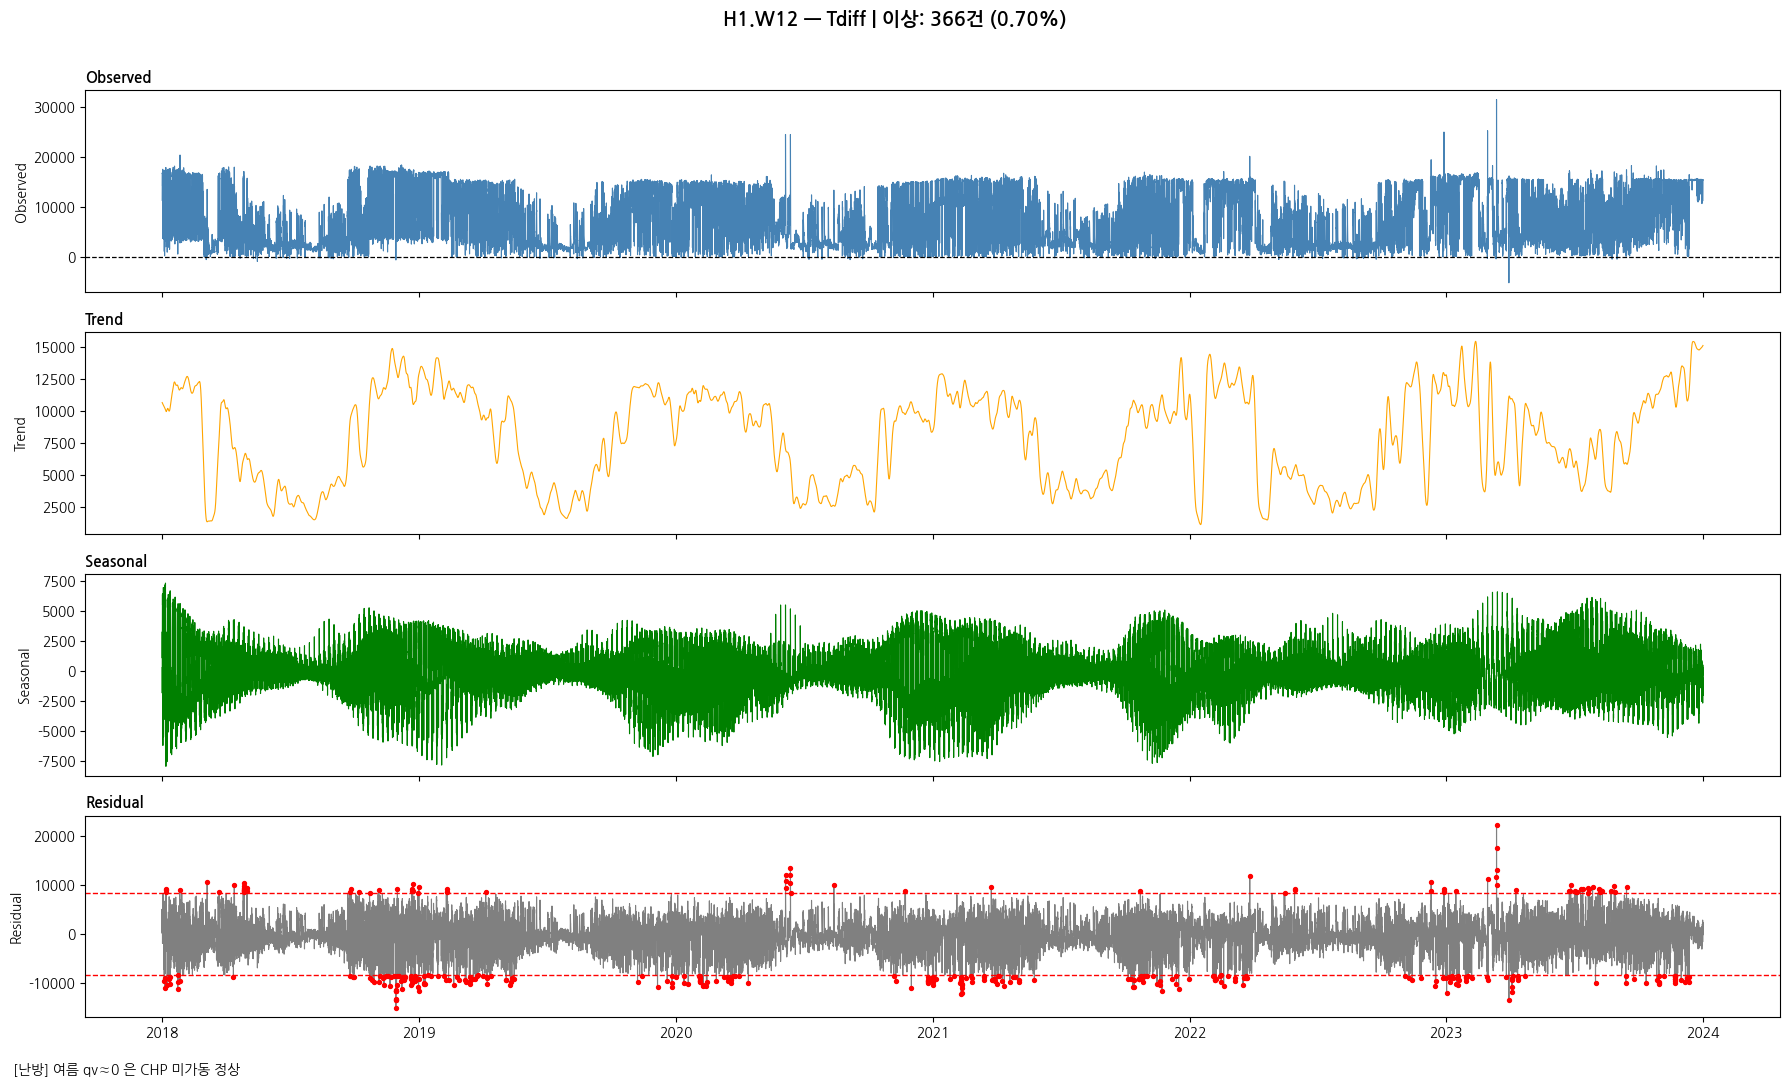

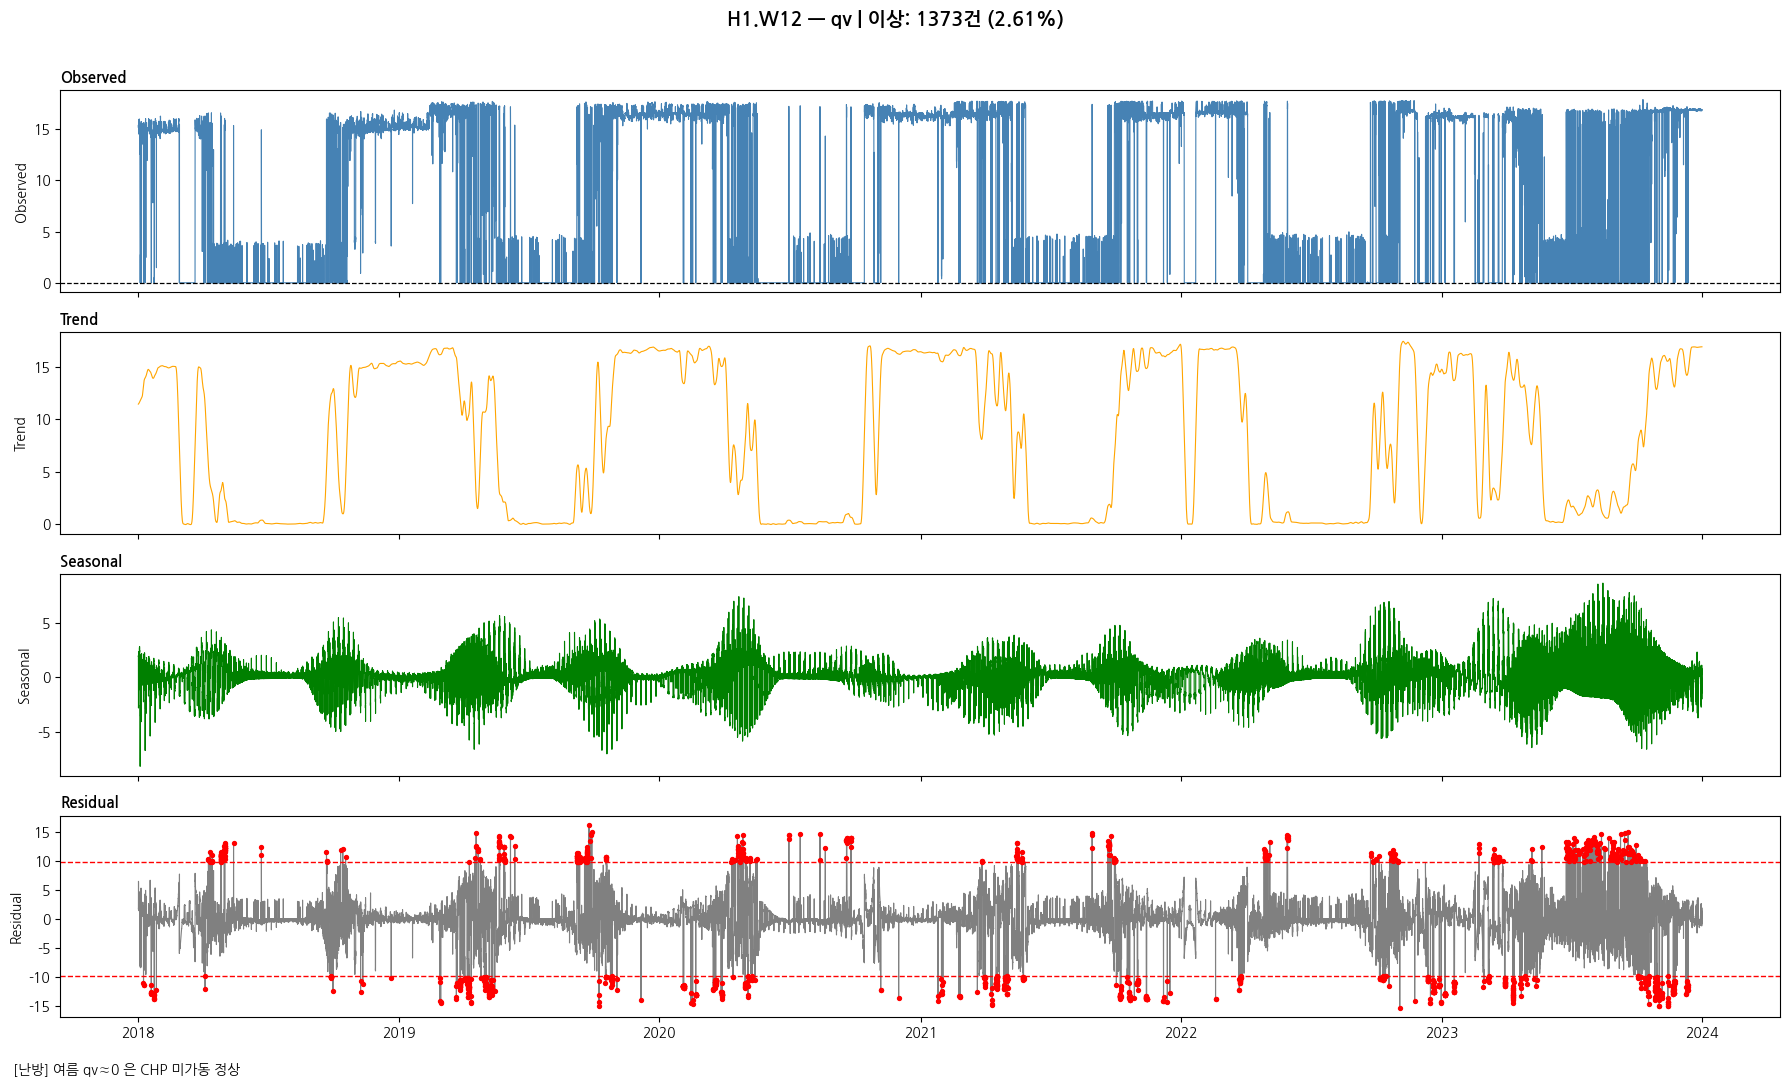

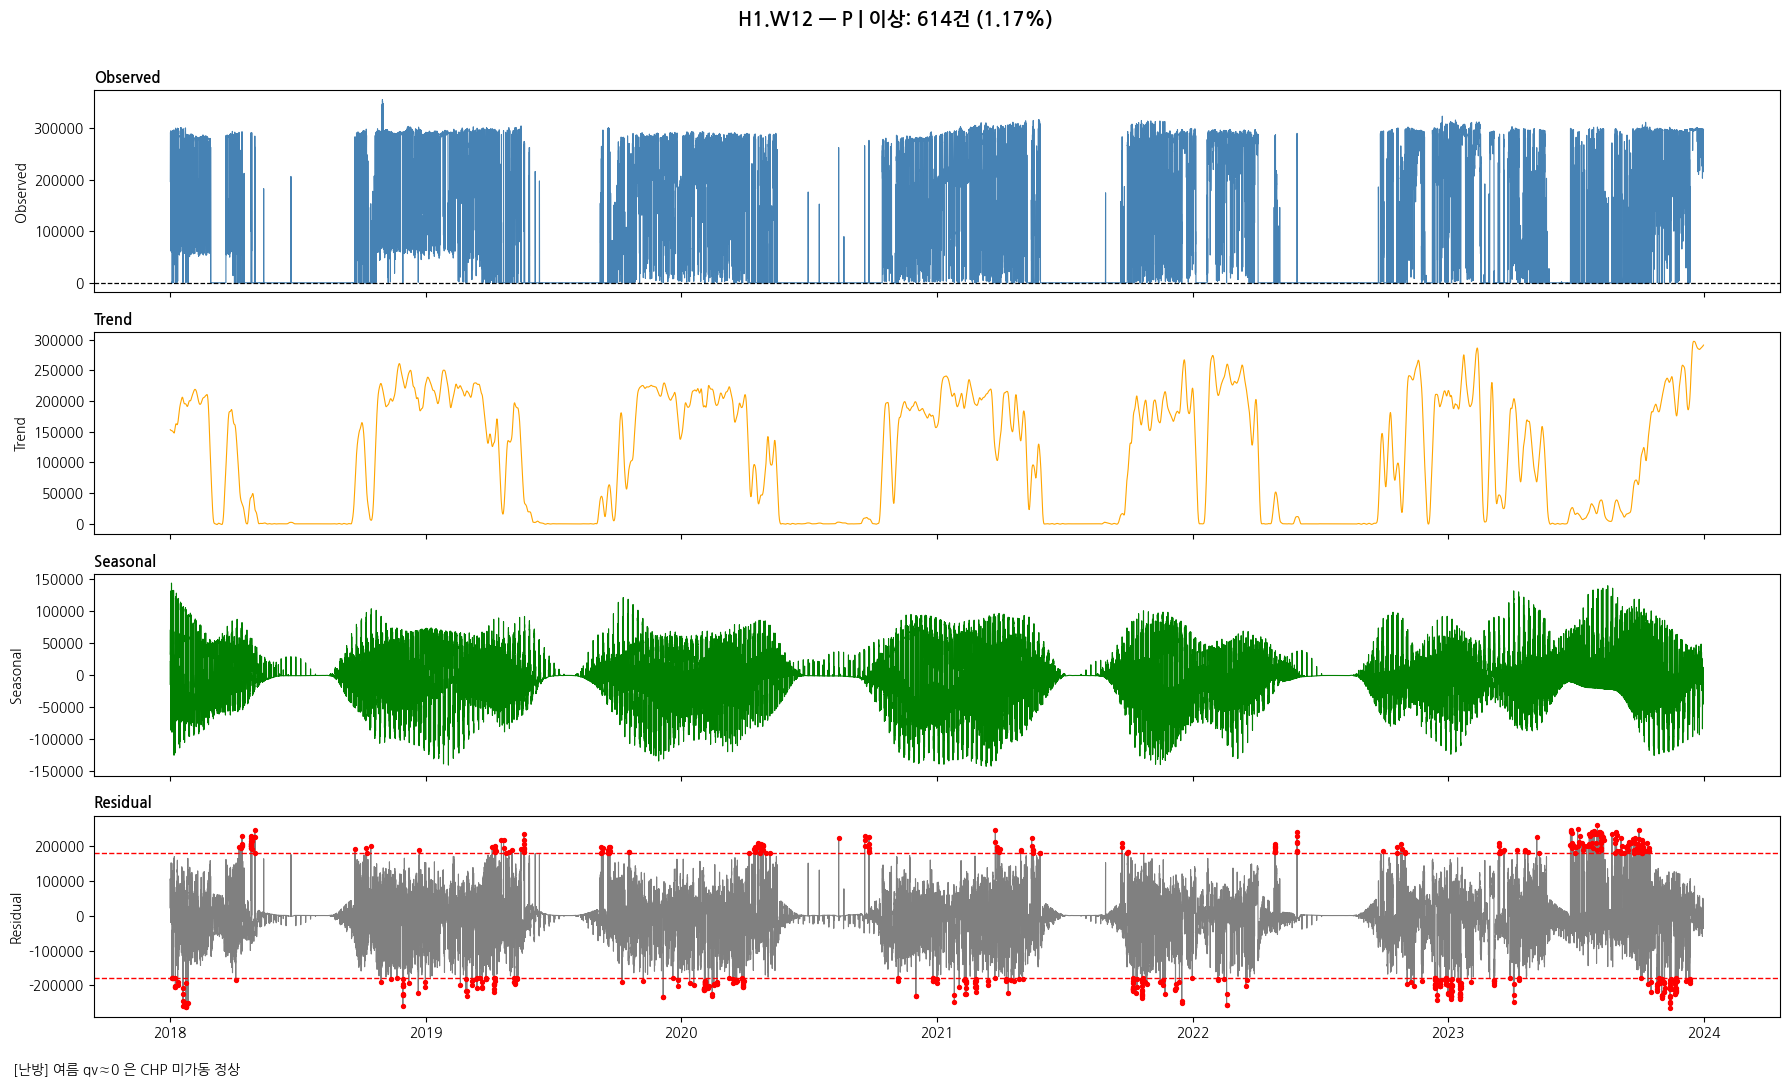

In [3]:
stl_results = {}
yearly_anomaly_rows = []
consecutive_anomaly_rows = []

for meter_urn, features in heat_meter_config.items():
    df = raw_meter_data[meter_urn].copy().sort_values('ts')
    stl_results[meter_urn] = {}

    for feature in features:
        series_df = df[['ts', feature]].copy()
        series_df[feature] = pd.to_numeric(series_df[feature], errors='coerce')
        series_df = series_df.dropna(subset=['ts']).drop_duplicates(subset=['ts']).sort_values('ts')
        series = series_df.set_index('ts')[feature]
        stl_input = series.dropna()

        if len(stl_input) < PERIOD:
            print(f'{meter_urn} - {feature}: STL 수행에 필요한 유효 데이터가 부족합니다.')
            continue

        result = STL(stl_input, period=PERIOD, seasonal=SEASONAL).fit()
        residual = result.resid
        mean = float(residual.mean())
        std = float(residual.std())
        upper = mean + SIGMA * std
        lower = mean - SIGMA * std
        anomaly_mask = (residual > upper) | (residual < lower)
        n_anomaly = int(anomaly_mask.sum())
        ratio = float(anomaly_mask.mean() * 100)

        yearly_counts = anomaly_mask.groupby(anomaly_mask.index.year).sum().astype(int)
        for year, count in yearly_counts.items():
            yearly_anomaly_rows.append({
                'meter': meter_urn,
                'feature': feature,
                'year': int(year),
                'n_anomaly': int(count),
            })

        anomaly_ts = residual[anomaly_mask].index.to_series()
        if not anomaly_ts.empty:
            segment_ids = anomaly_ts.diff().ne(pd.Timedelta(hours=1)).cumsum()
            for _, segment in anomaly_ts.groupby(segment_ids):
                duration_hours = int(len(segment))
                if duration_hours >= 24:
                    consecutive_anomaly_rows.append({
                        'meter': meter_urn,
                        'feature': feature,
                        'start': segment.iloc[0],
                        'end': segment.iloc[-1],
                        'duration_hours': duration_hours,
                    })

        stl_results[meter_urn][feature] = {
            'result': result,
            'residual': residual,
            'anomaly_mask': anomaly_mask,
            'upper': upper,
            'lower': lower,
            'n_anomaly': n_anomaly,
            'ratio': ratio,
        }

        fig, axes = plt.subplots(4, 1, figsize=(18, 11), sharex=True)
        fig.suptitle(f'{meter_urn} — {feature} | 이상: {n_anomaly}건 ({ratio:.2f}%)', fontsize=14, fontweight='bold')

        observed = result.observed
        trend = result.trend
        seasonal = result.seasonal

        axes[0].plot(observed.index, observed.values, color='steelblue', lw=0.8)
        axes[0].axhline(0, color='black', linestyle='--', lw=0.9)
        axes[0].set_ylabel('Observed')
        axes[0].set_title('Observed', loc='left', fontsize=11, fontweight='bold')

        for start, end, color, label in SPECIAL_PERIODS.get(meter_urn, []):
            start_ts = pd.Timestamp(start, tz='UTC')
            end_ts = pd.Timestamp(end, tz='UTC')
            axes[0].axvspan(start_ts, end_ts, color=color, alpha=0.2)
            axes[0].text(start_ts, axes[0].get_ylim()[1], label, color=color, fontsize=9, va='top')

        axes[1].plot(trend.index, trend.values, color='orange', lw=0.8)
        axes[1].set_ylabel('Trend')
        axes[1].set_title('Trend', loc='left', fontsize=11, fontweight='bold')

        axes[2].plot(seasonal.index, seasonal.values, color='green', lw=0.8)
        axes[2].set_ylabel('Seasonal')
        axes[2].set_title('Seasonal', loc='left', fontsize=11, fontweight='bold')

        axes[3].plot(residual.index, residual.values, color='gray', lw=0.8)
        axes[3].axhline(upper, color='red', linestyle='--', lw=1)
        axes[3].axhline(lower, color='red', linestyle='--', lw=1)
        axes[3].scatter(residual[anomaly_mask].index, residual[anomaly_mask].values, color='red', s=8, zorder=5)
        axes[3].set_ylabel('Residual')
        axes[3].set_title('Residual', loc='left', fontsize=11, fontweight='bold')

        meter_type_label = '냉각' if meter_urn in COOLING else '난방' if meter_urn in HEATING else '기타'
        note = METER_NOTES.get(meter_urn, '-')
        fig.text(0.01, 0.01, f'[{meter_type_label}] {note}', ha='left', va='bottom', fontsize=10)
        fig.tight_layout(rect=[0, 0.03, 1, 0.97])
        plt.show()


In [4]:
yearly_df = pd.DataFrame(yearly_anomaly_rows)
if yearly_df.empty:
    print('요약할 이상 건수가 없습니다.')
else:
    yearly_pivot = (
        yearly_df.pivot_table(
            index=['meter', 'feature'],
            columns='year',
            values='n_anomaly',
            aggfunc='sum',
            fill_value=0,
        )
        .sort_index()
    )
    display(yearly_pivot)


year            2018  2019  2020  2021  2022  2023
meter  feature                                    
H1.K11 P          14    28    21    41    41   195
       Tdiff      20    53   145   346   162   184
       qv         80    20    70    82    89  1022
H1.K12 P         230   338   331   183     3     0
       Tdiff      18   383   353   243   140     0
H1.K14 P         151   104   237   229   290   143
       Tdiff     410   322   110    68   144    33
       qv        175   492   175   362   122    46
H1.K15 P         167   128   111   187   121   211
       Tdiff     124    71   234   244   149   136
H1.K16 P           0     0     0     0     0   213
       Tdiff       0     1    25   353    17   293
       qv          0    11   373   191    89    13
H1.W11 P          98    96    50   139    37    42
       Tdiff       2     0     0     3     3  1113
       qv         77     4    75     6    28  1176
H1.W12 P          70    75    95    92    64   218
       Tdiff      91    44    49    64    36    82
       qv         98   273   185   253   170   394
H2.K21 P         272   232   244   214   308   234
       Tdiff      74   121   167   257   154   297
       qv        193   153   398   231   229    50
V.K21  P         101    61   183    84   101    99
       Tdiff      26     2    70   351   399   141
       qv         76   217   225   262    19     0

In [5]:
consecutive_df = pd.DataFrame(consecutive_anomaly_rows).sort_values(['meter', 'feature', 'start']) if consecutive_anomaly_rows else pd.DataFrame()

if consecutive_df.empty:
    print('연속 24시간 이상 이상 구간이 없습니다.')
else:
    for (meter, feature), group in consecutive_df.groupby(['meter', 'feature'], sort=True):
        print(f'[{meter} {feature}]')
        for row in group.itertuples(index=False):
            start_str = row.start.tz_convert('Asia/Seoul').strftime('%Y-%m-%d')
            end_str = row.end.tz_convert('Asia/Seoul').strftime('%Y-%m-%d')
            print(f'  {start_str} ~ {end_str} ({row.duration_hours}시간)')
        print()


[H1.K11 Tdiff]
  2021-10-21 ~ 2021-10-22 (26시간)
  2021-10-23 ~ 2021-10-26 (66시간)
  2021-11-04 ~ 2021-11-06 (48시간)
  2021-11-07 ~ 2021-11-09 (49시간)
  2022-05-14 ~ 2022-05-15 (31시간)
  2023-01-11 ~ 2023-01-13 (46시간)
  2023-04-30 ~ 2023-05-02 (37시간)

[H1.K11 qv]
  2018-07-19 ~ 2018-07-20 (27시간)
  2018-10-31 ~ 2018-11-01 (45시간)
  2020-03-16 ~ 2020-03-17 (29시간)
  2021-10-20 ~ 2021-10-21 (31시간)
  2021-10-21 ~ 2021-10-22 (32시간)
  2022-05-31 ~ 2022-06-01 (36시간)
  2022-06-01 ~ 2022-06-02 (25시간)
  2023-01-08 ~ 2023-01-11 (72시간)
  2023-01-11 ~ 2023-01-14 (71시간)
  2023-03-21 ~ 2023-03-27 (137시간)
  2023-03-27 ~ 2023-03-29 (37시간)
  2023-04-28 ~ 2023-05-02 (91시간)
  2023-07-16 ~ 2023-07-17 (34시간)
  2023-08-19 ~ 2023-08-22 (71시간)

[H1.K12 P]
  2018-05-29 ~ 2018-05-30 (24시간)
  2019-05-25 ~ 2019-05-26 (29시간)
  2019-06-27 ~ 2019-06-28 (25시간)
  2019-07-10 ~ 2019-07-11 (25시간)
  2020-09-05 ~ 2020-09-06 (32시간)
  2020-09-21 ~ 2020-09-22 (26시간)
  2020-10-22 ~ 2020-10-23 (24시간)
  2021-08-12 ~ 2021-08-13 (25시간)
  